#PCA


 Note :

This notebook includes additional images, screenshots, diagrams, and explanatory notes in some sections to support my understanding of the concepts.

 I incorporated these materials as part of my learning process and to create useful study notes for future reference.

  The primary objective was to understand the concepts thoroughly while completing the assignment.

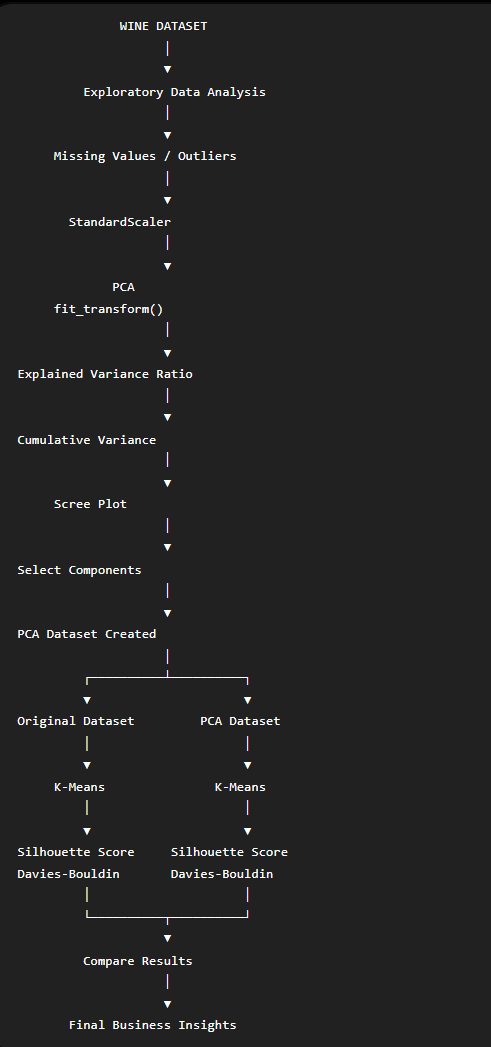

| Method / Parameter          | Meaning                                          | Simple Memory Trick      |
| --------------------------- | ------------------------------------------------ | ------------------------ |
| `fit()`                     | Learn from the data                              | 📖 Study                 |
| `transform()`               | Change the data                                  | 🔄 Convert               |
| `fit_transform()`           | Learn + Convert                                  | 📖 + 🔄                  |
| `predict()`                 | Make predictions                                 | 🎯 Answer                |
| `fit_predict()`             | Learn + Assign labels                            | 📖 + 🏷️                 |
| `random_state`              | Reproducible results                             | 🔒 Same result every run |
| `n_clusters`                | Number of clusters                               | 👥 Number of groups      |
| `n_components`              | Number of principal components                   | 📉 Features to keep      |
| `cluster_centers_`          | Center of each cluster                           | 📍 Cluster midpoint      |
| `explained_variance_ratio_` | Information captured by each principal component | 📚 Information retained  |


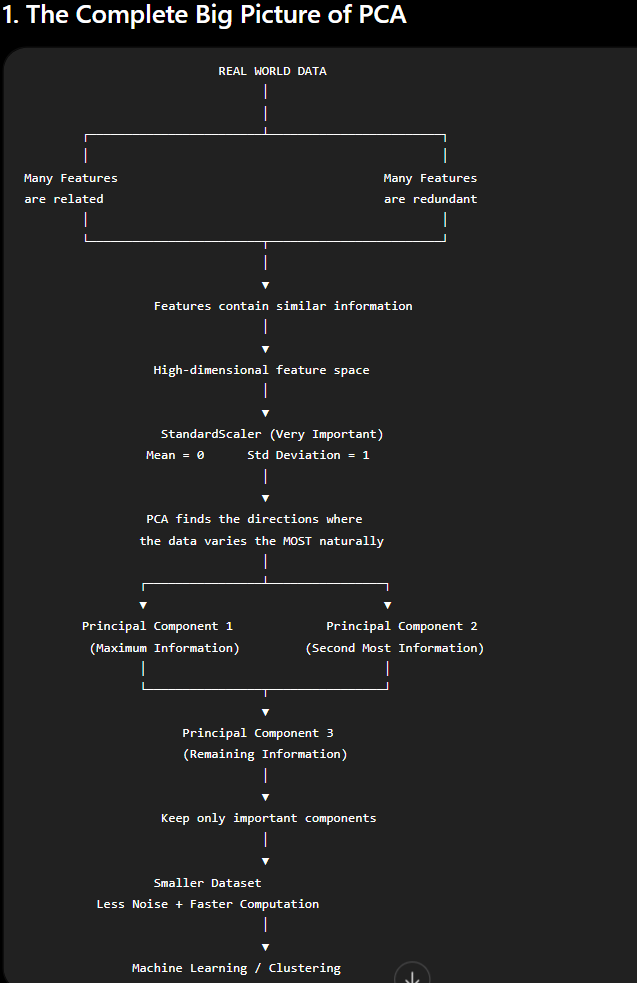

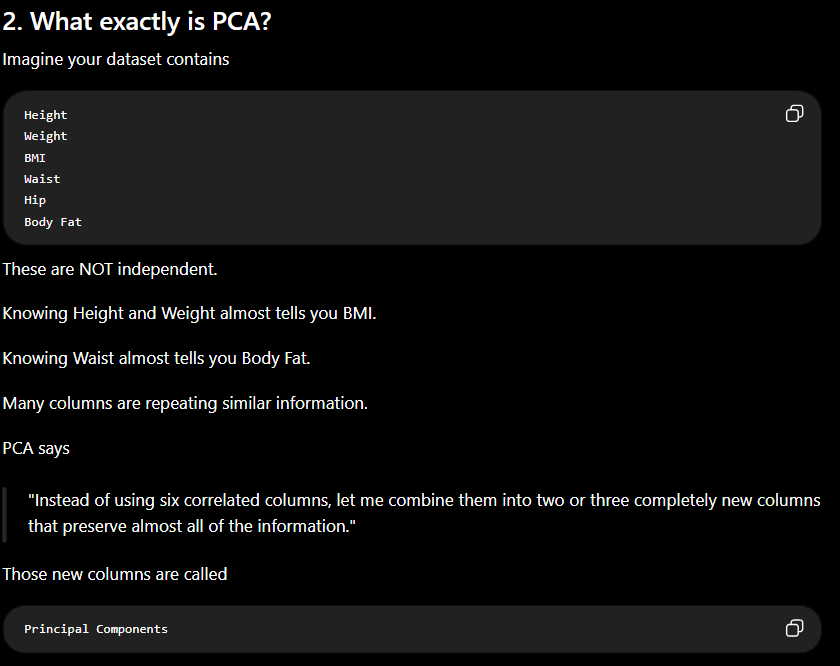

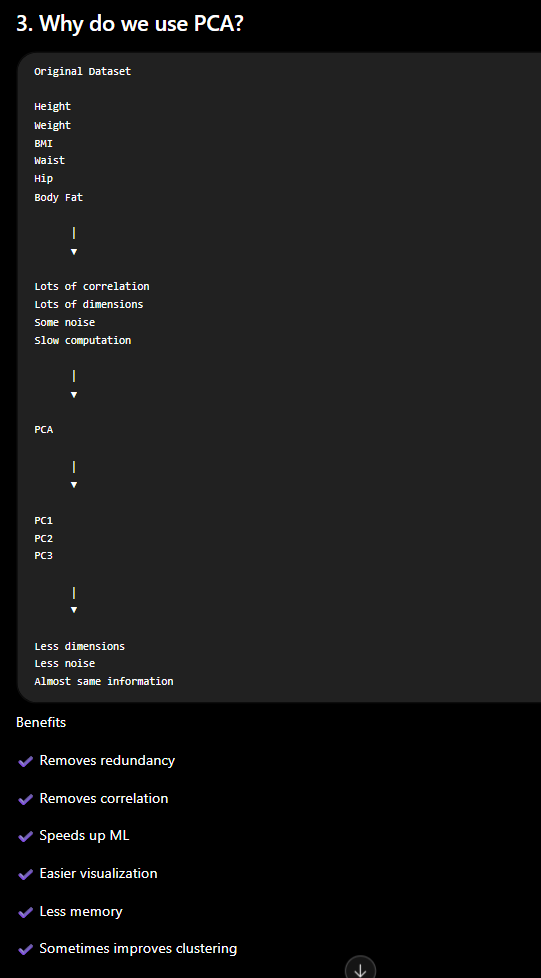

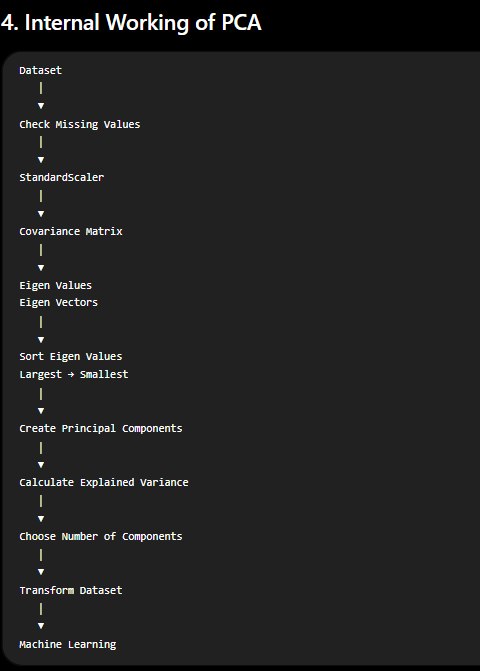

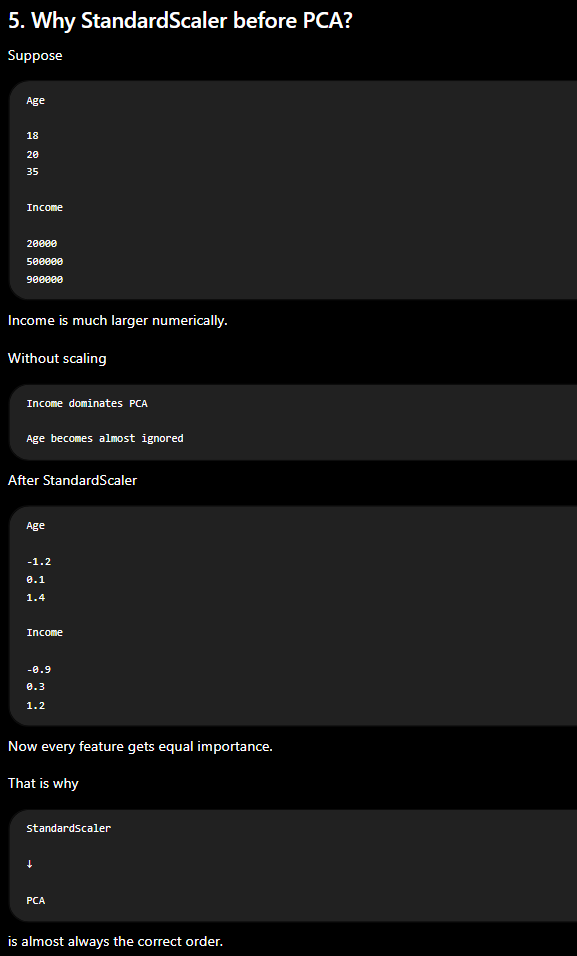

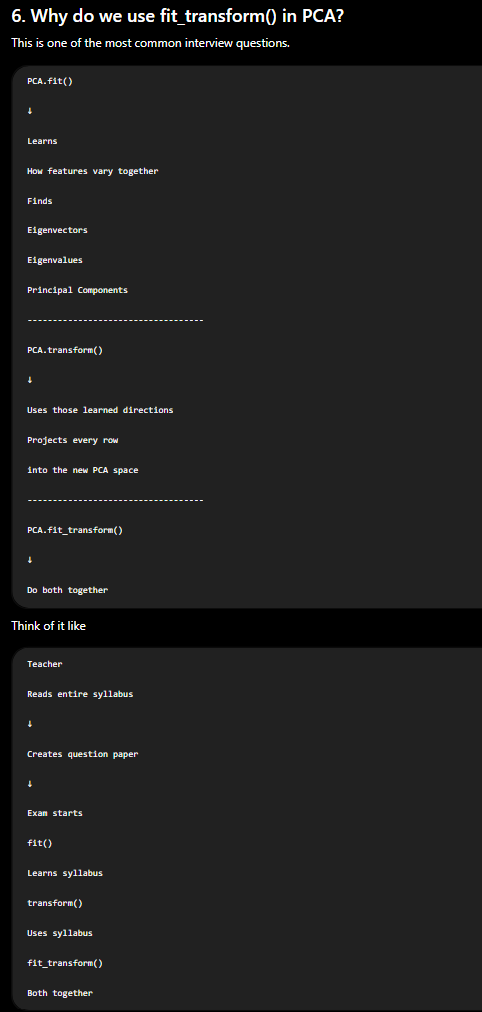

we can aslo say as we are not only learning pattrens from the data but we are transforming the data into new components that is why we are using the fit_transform

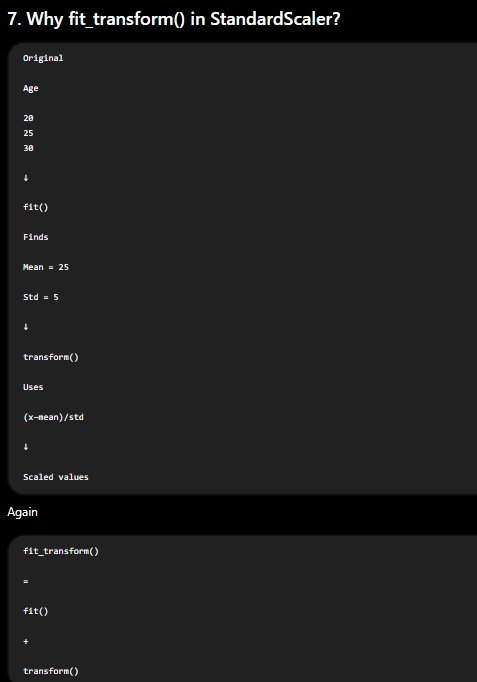

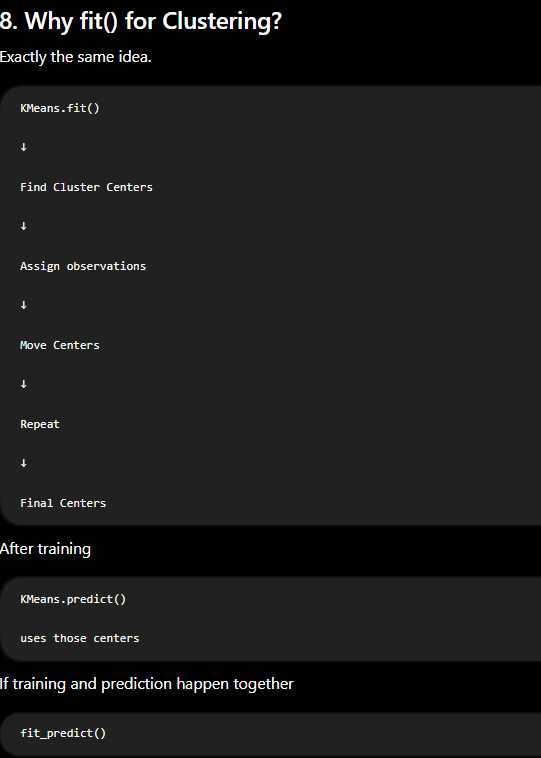

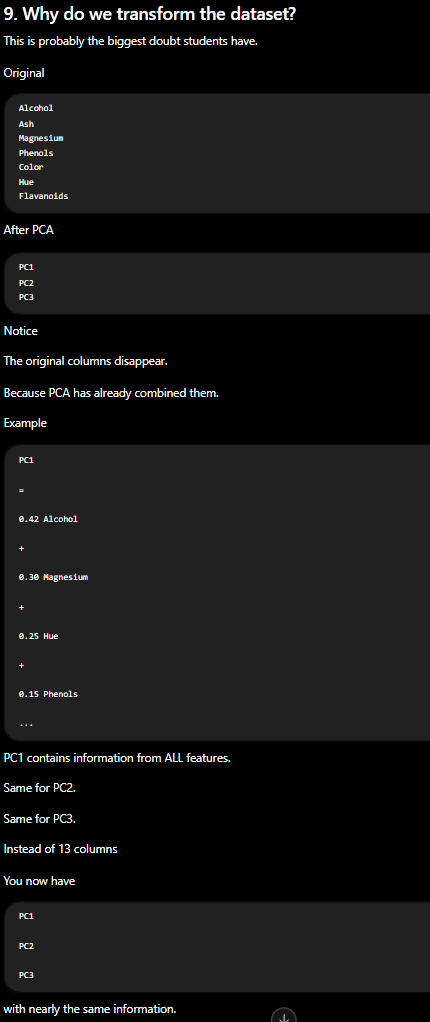

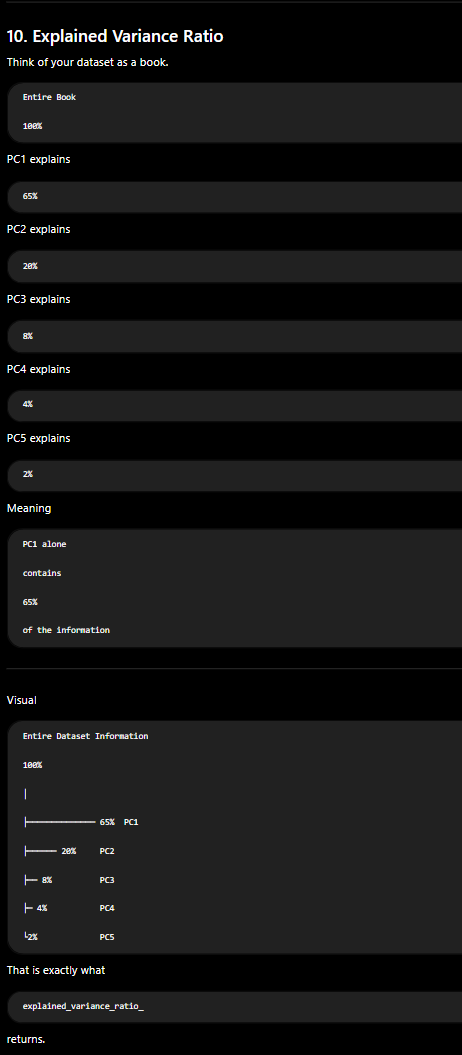

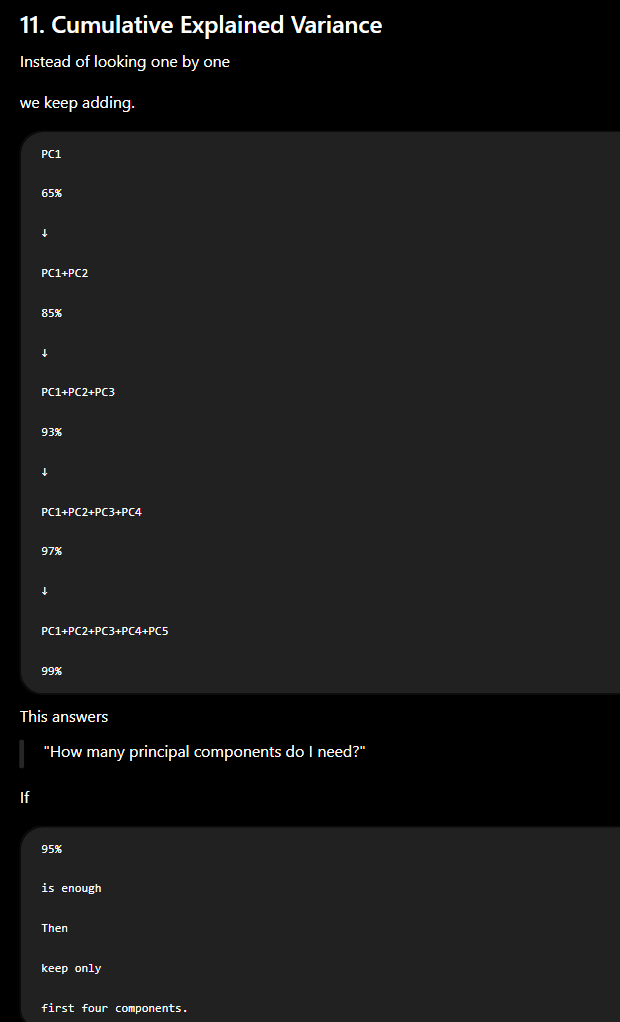

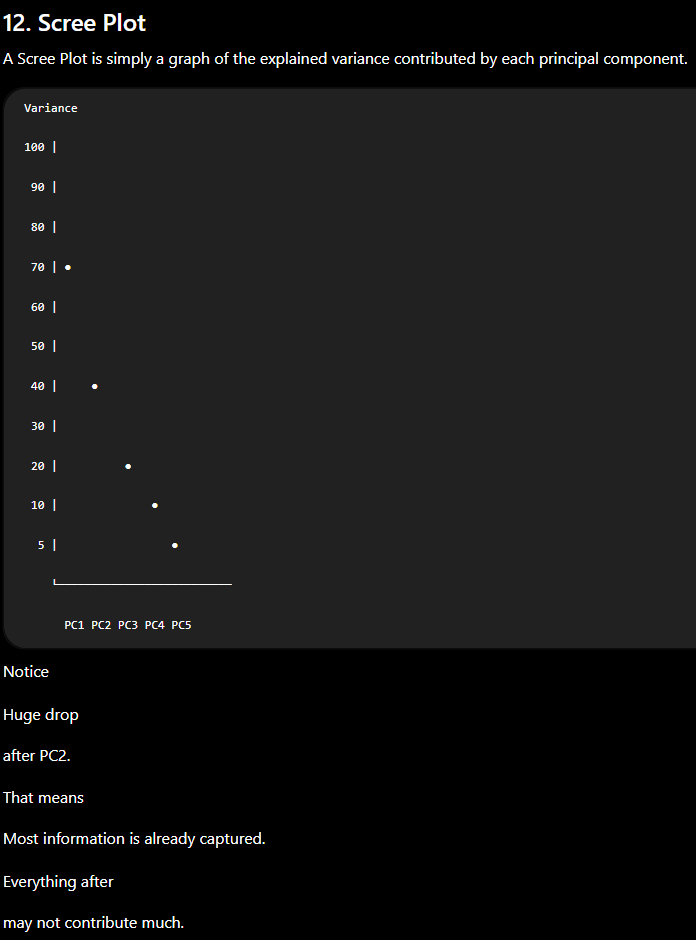

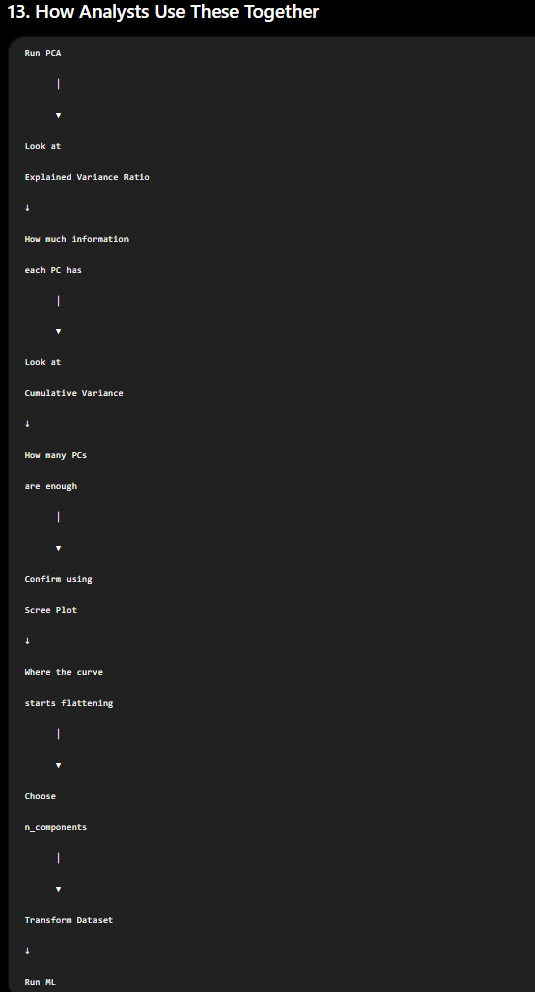

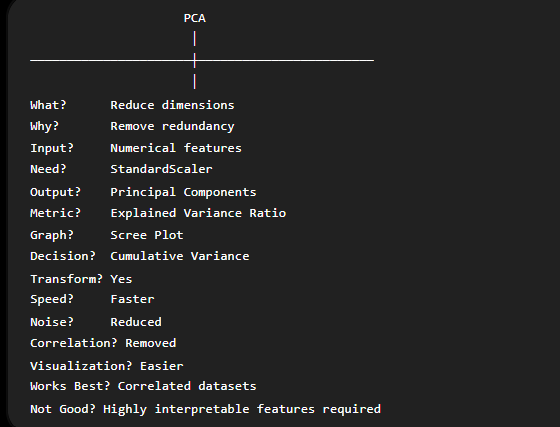

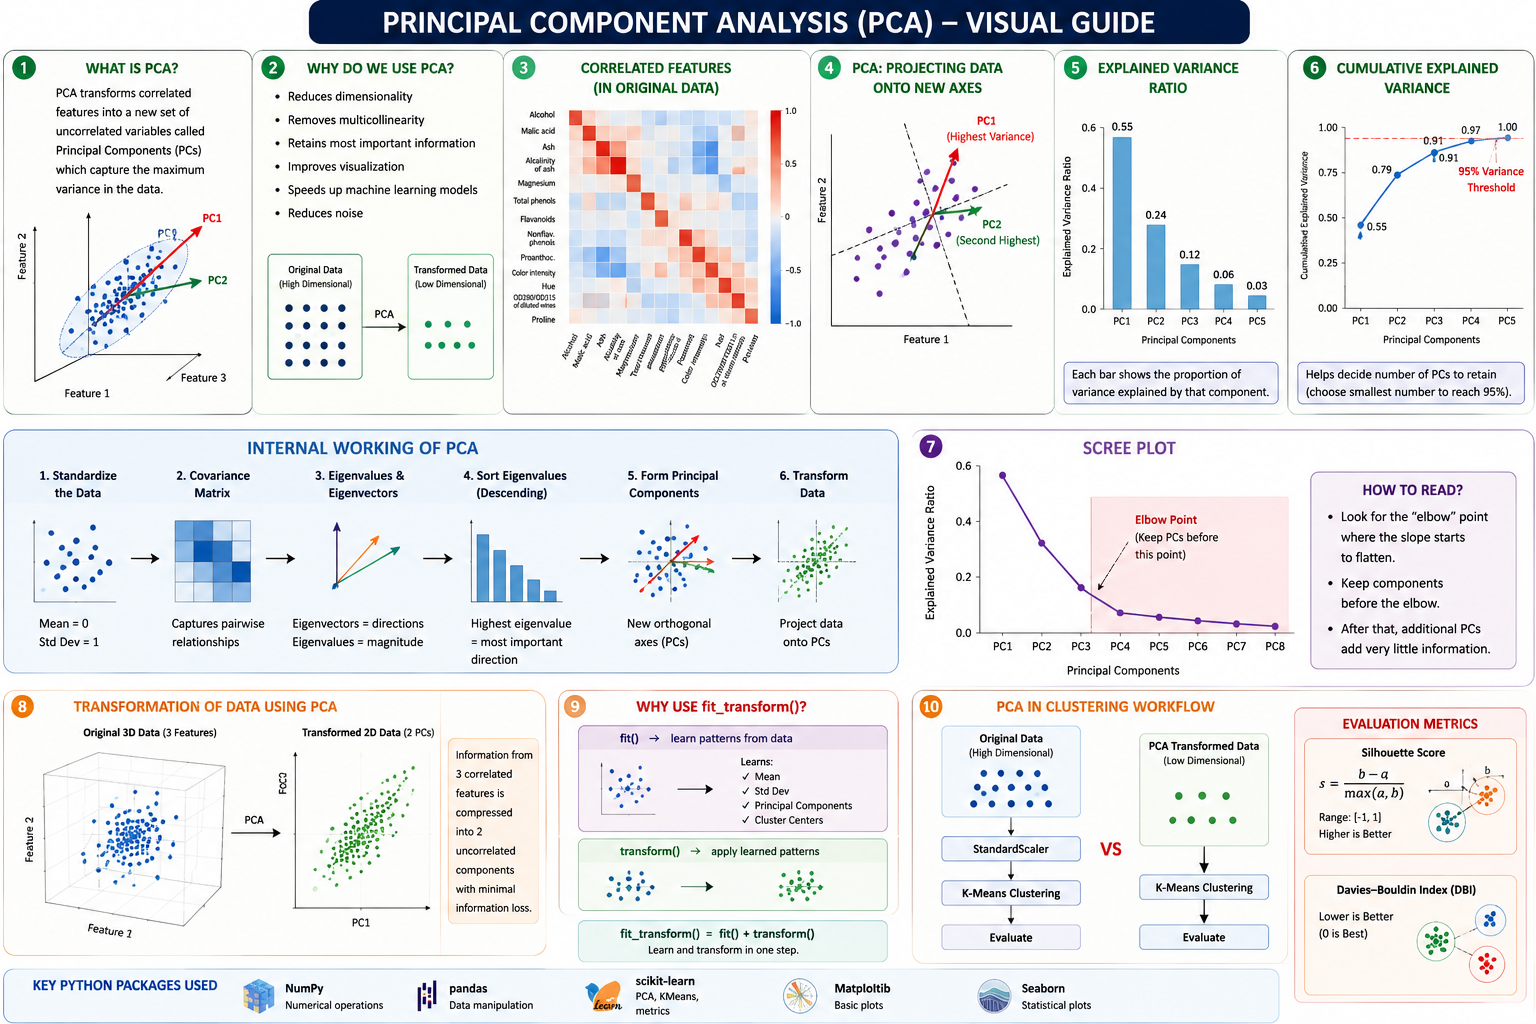

In [206]:
import pandas as pd
import numpy as np

In [207]:
df = pd.read_csv('/content/wine.csv')

In [208]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [209]:
df.shape

(178, 14)

In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [211]:
df.sample(5)

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
49,1,13.94,1.73,2.27,17.4,108,2.88,3.54,0.32,2.08,8.90,1.12,3.10,1260
33,1,13.76,1.53,2.70,19.5,132,2.95,2.74,0.50,1.35,5.40,1.25,3.00,1235
129,2,12.04,4.30,2.38,22.0,80,2.10,1.75,0.42,1.35,2.60,0.79,2.57,580
118,2,12.77,3.43,1.98,16.0,80,1.63,1.25,0.43,0.83,3.40,0.70,2.12,372
63,2,12.37,1.13,2.16,19.0,87,3.50,3.10,0.19,1.87,4.45,1.22,2.87,420


In [212]:
df.columns

Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

In [213]:
df.dtypes

,0
Type,int64
Alcohol,float64
Malic,float64
Ash,float64
Alcalinity,float64
Magnesium,int64
Phenols,float64
Flavanoids,float64
Nonflavanoids,float64
Proanthocyanins,float64


In [214]:
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


In [215]:
df.duplicated().sum()

np.int64(0)

In [216]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [217]:
import matplotlib.pyplot as plt
import seaborn as sns

In [218]:
numerical_columns = [
    'Alcohol',	'Malic',	'Ash',	'Alcalinity',	'Magnesium',	'Phenols',	'Flavanoids',	'Nonflavanoids',	'Proanthocyanins',	'Color',	'Hue',	'Dilution',	'Proline'
]


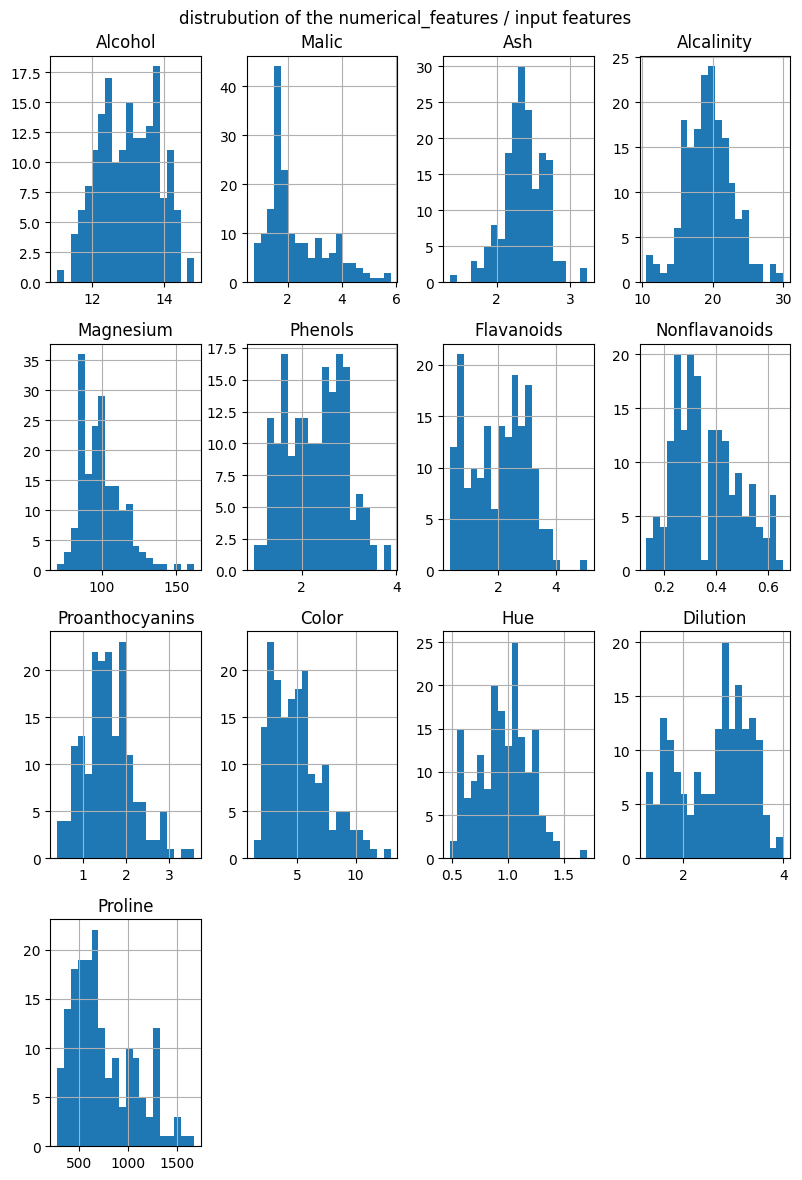

In [219]:
df[numerical_columns].hist(
    figsize = (8,12),
    bins = 20
)
plt.suptitle('distrubution of the numerical_features / input features ')
plt.tight_layout()
plt.show()

The histograms show the distribution of each numerical feature in the wine dataset. Most features exhibit different ranges and distribution patterns, indicating that feature scaling is necessary before applying PCA. Some variables also appear slightly skewed, suggesting differences in variance across features.

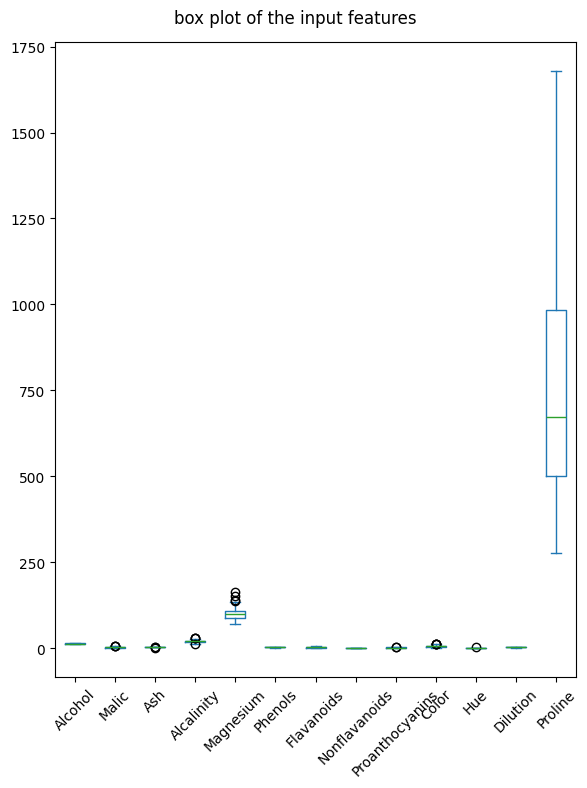

In [220]:
df[numerical_columns].plot(
    figsize = (6,8),
    kind = 'box',
    layout = (3,5)
)
plt.suptitle('box plot of the input features')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

The boxplots indicate the presence of outliers in several numerical features. PCA is generally robust to moderate outliers after standardization, but identifying them helps us better understand the dataset before dimensionality reduction.

In [221]:
co_relation = df.corr()
co_relation

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
Type,1.000000,-0.328222,0.437776,-0.049643,0.517859,-0.209179,-0.719163,-0.847498,0.489109,-0.499130,0.265668,-0.617369,-0.788230,-0.633717
Alcohol,-0.328222,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
Malic,0.437776,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
Ash,-0.049643,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
Alcalinity,0.517859,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
Magnesium,-0.209179,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
Phenols,-0.719163,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
Flavanoids,-0.847498,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
Nonflavanoids,0.489109,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
Proanthocyanins,-0.499130,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417


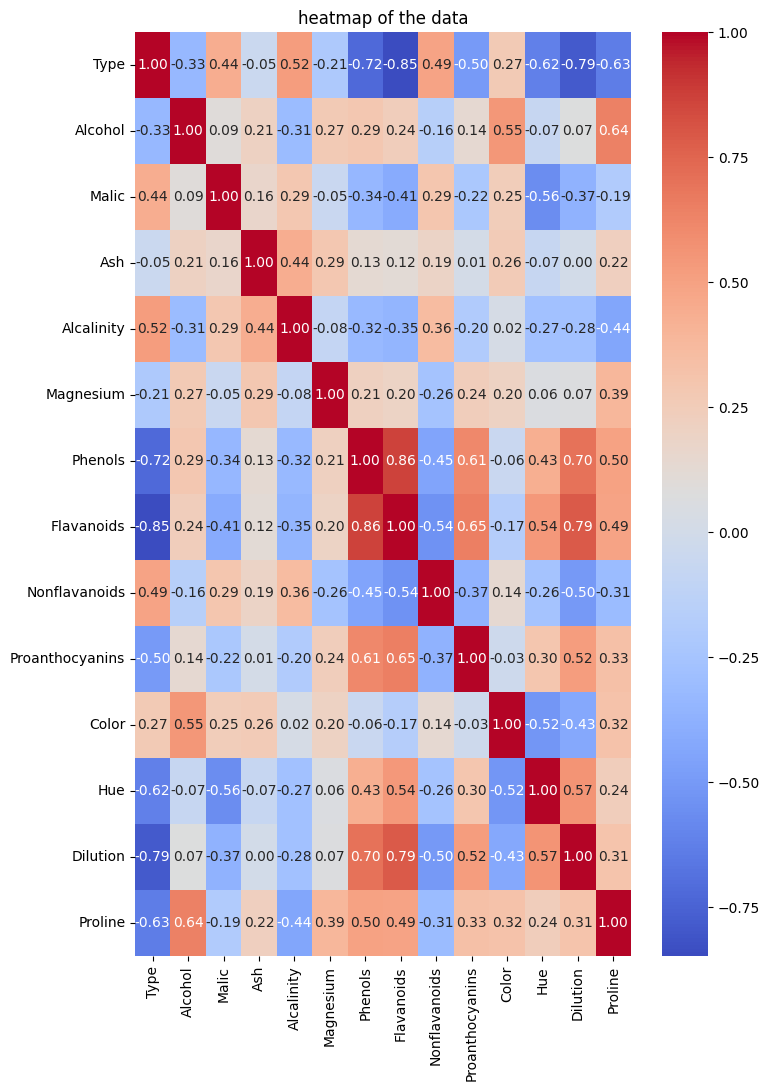

In [222]:
plt.figure(figsize=(8,12))

sns.heatmap(
    co_relation,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f'
)
plt.title('heatmap of the data')
plt.show()


The heatmap shows the relationships between all numerical variables.

Highly correlated features indicate that they contain similar information.

This suggests redundancy within the dataset.

Since PCA is specifically designed to reduce redundancy and multicollinearity,
the presence of correlated variables justifies applying PCA.

Business Insight:

Reducing redundant variables allows analysts to simplify the dataset without losing significant information, leading to faster and more efficient analysis.

####Dimensionality Reduction with PCA

Original Dataset

       │
       ▼
Separate Features & Target

       │
       ▼
Standardize Features

       │
       ▼
Apply PCA

       │
       ▼
Find Explained Variance

       │
       ▼
Scree Plot

       │
       ▼
Cumulative Explained Variance

       │
       ▼
Choose Number of Components

       │
       ▼
Transform Dataset

In [223]:
X = df.drop("Type", axis=1)

y = df["Type"]

In [224]:
X.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [225]:
y.head()

,Type
0,1
1,1
2,1
3,1
4,1


In [226]:
# Data Preprocessing
from sklearn.preprocessing import StandardScaler

In [227]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [228]:
X_scaled # viewing of the scaled data in 1d

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]])

In [229]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head() # viewing of the scaled data in 2d

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


Since the variables are measured on different scales
(e.g., Alcohol, Magnesium, Proline),

features with larger numerical values would dominate the PCA calculation.

StandardScaler ensures that every feature contributes equally.

Business Insight:

The transformed dataset prevents large-scale variables from biasing dimensionality reduction, resulting in more reliable principal components.

In [230]:
from sklearn.decomposition import PCA

In [231]:
pca = PCA() # applying pca

X_pca = pca.fit_transform(X_scaled)

In [232]:
pca.explained_variance_ratio_ # This tells you how much information (variance) each principal component captures.

array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294,
       0.04935823, 0.04238679, 0.02680749, 0.02222153, 0.01930019,
       0.01736836, 0.01298233, 0.00795215])

In [233]:
explained_variance = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance": pca.explained_variance_ratio_
})

explained_variance

,Principal Component,Explained Variance
0,PC1,0.361988
1,PC2,0.192075
2,PC3,0.111236
3,PC4,0.070690
4,PC5,0.065633
5,PC6,0.049358
6,PC7,0.042387
7,PC8,0.026807
8,PC9,0.022222
9,PC10,0.019300


The first principal component captures the largest amount of variation present in the original dataset.

This indicates that most of the important information is concentrated within the first few principal components.

Business Insight:

Instead of analyzing all original variables individually,
analysts can focus on a smaller number of components while retaining most of the dataset's information.

In [234]:
explained_variance["Cumulative Variance"] = explained_variance["Explained Variance"].cumsum()

explained_variance

,Principal Component,Explained Variance,Cumulative Variance
0,PC1,0.361988,0.361988
1,PC2,0.192075,0.554063
2,PC3,0.111236,0.665300
3,PC4,0.070690,0.735990
4,PC5,0.065633,0.801623
5,PC6,0.049358,0.850981
6,PC7,0.042387,0.893368
7,PC8,0.026807,0.920175
8,PC9,0.022222,0.942397
9,PC10,0.019300,0.961697


The cumulative explained variance indicates that the first 10 principal components preserve approximately 95% of the original information.

This means that the remaining components contribute very little additional information.

Business Insight:

Using only 10 principal components reduces computational complexity while maintaining nearly all useful information contained in the original dataset.

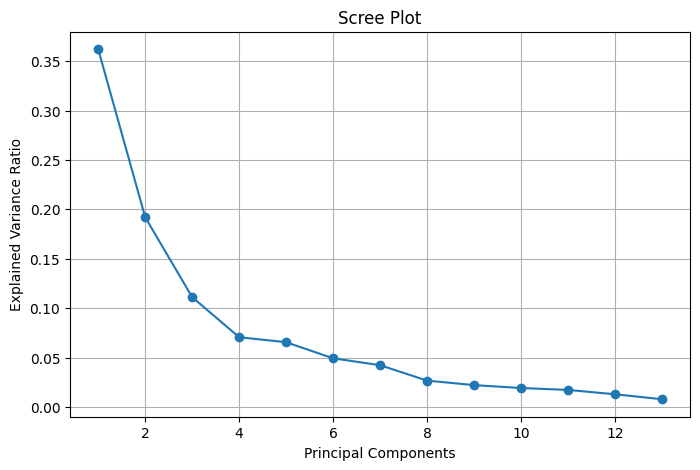

In [235]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.grid(True)

plt.show()

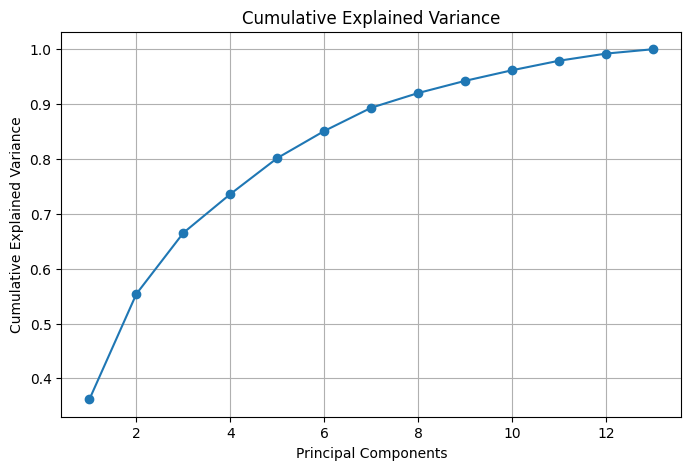

In [236]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1), # simply treat this line a range variable start stop and iteration then it will be easy  to understand
    explained_variance["Cumulative Variance"],
    marker="o"
)

plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.grid(True)

plt.show()

Most of the useful information is concentrated in the first few Principal Components.

The remaining components contribute only a small amount of additional information.

Keeping the first 10 Principal Components is enough to preserve almost all of the original dataset while reducing dimensionality.

"The graph shows the total percentage of information retained as principal components are added one by one. It helps determine how many principal components should be kept. In this dataset, the first 10 principal components retain about 96% of the original variance, so they provide an effective balance between dimensionality reduction and information preservation."

In [237]:
explained_variance

,Principal Component,Explained Variance,Cumulative Variance
0,PC1,0.361988,0.361988
1,PC2,0.192075,0.554063
2,PC3,0.111236,0.665300
3,PC4,0.070690,0.735990
4,PC5,0.065633,0.801623
5,PC6,0.049358,0.850981
6,PC7,0.042387,0.893368
7,PC8,0.026807,0.920175
8,PC9,0.022222,0.942397
9,PC10,0.019300,0.961697


In [238]:
pca = PCA(n_components=10) # one thing to notice is we are using fit_transform for the pca

X_pca = pca.fit_transform(X_scaled)

In [239]:
X_pca

array([[ 3.31675081e+00,  1.44346263e+00, -1.65739045e-01, ...,
        -6.51390947e-02, -6.41442706e-01,  1.02095585e+00],
       [ 2.20946492e+00, -3.33392887e-01, -2.02645737e+00, ...,
        -1.02441595e+00,  3.08846753e-01,  1.59701372e-01],
       [ 2.51674015e+00,  1.03115130e+00,  9.82818670e-01, ...,
         3.44216131e-01,  1.17783447e+00,  1.13360857e-01],
       ...,
       [-2.67783946e+00,  2.76089913e+00, -9.40941877e-01, ...,
        -4.70238043e-02, -1.22214687e-03, -2.47997312e-01],
       [-2.38701709e+00,  2.29734668e+00, -5.50696197e-01, ...,
        -3.90828774e-01, -5.74476725e-02,  4.91489502e-01],
       [-3.20875816e+00,  2.76891957e+00,  1.01391366e+00, ...,
         2.92913734e-01, -7.41660423e-01, -1.17969019e-01]])

In [240]:
X_pca = pd.DataFrame(
    X_pca, # Take the NumPy array called X_pca and convert it into a pandas DataFrame.
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

X_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139,-0.641443,1.020956
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416,0.308847,0.159701
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216,1.177834,0.113361
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593,-0.052544,0.239413
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700,-0.326819,-0.078366


In [241]:
X_pca.shape

(178, 10)

#### Clustering with Original Data

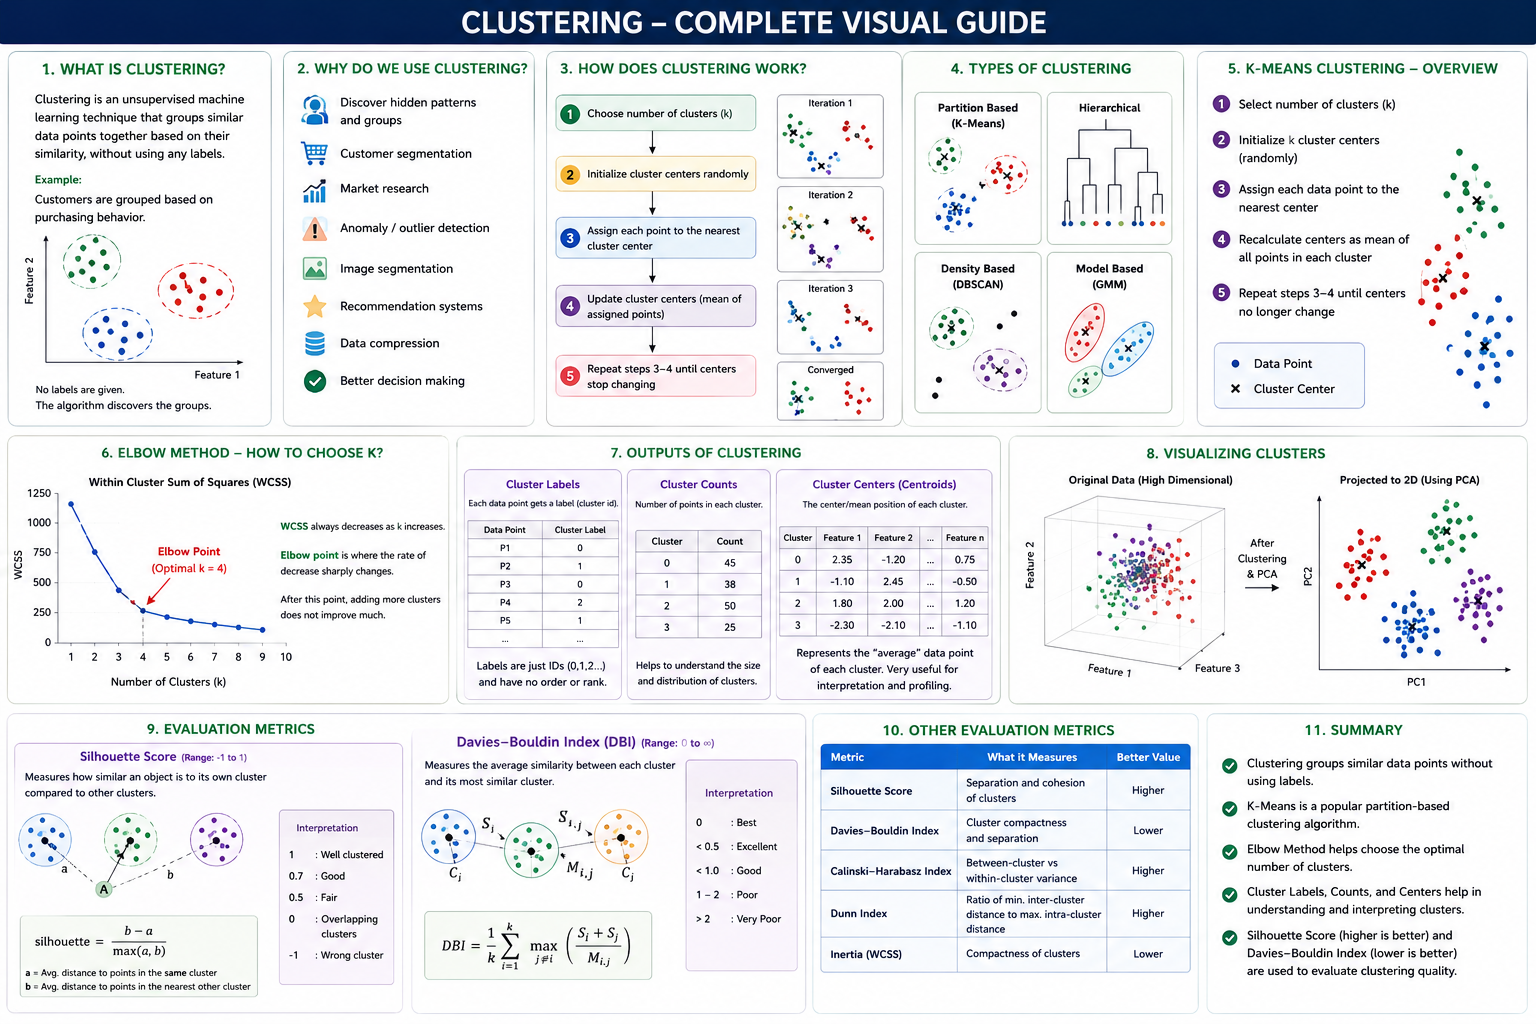

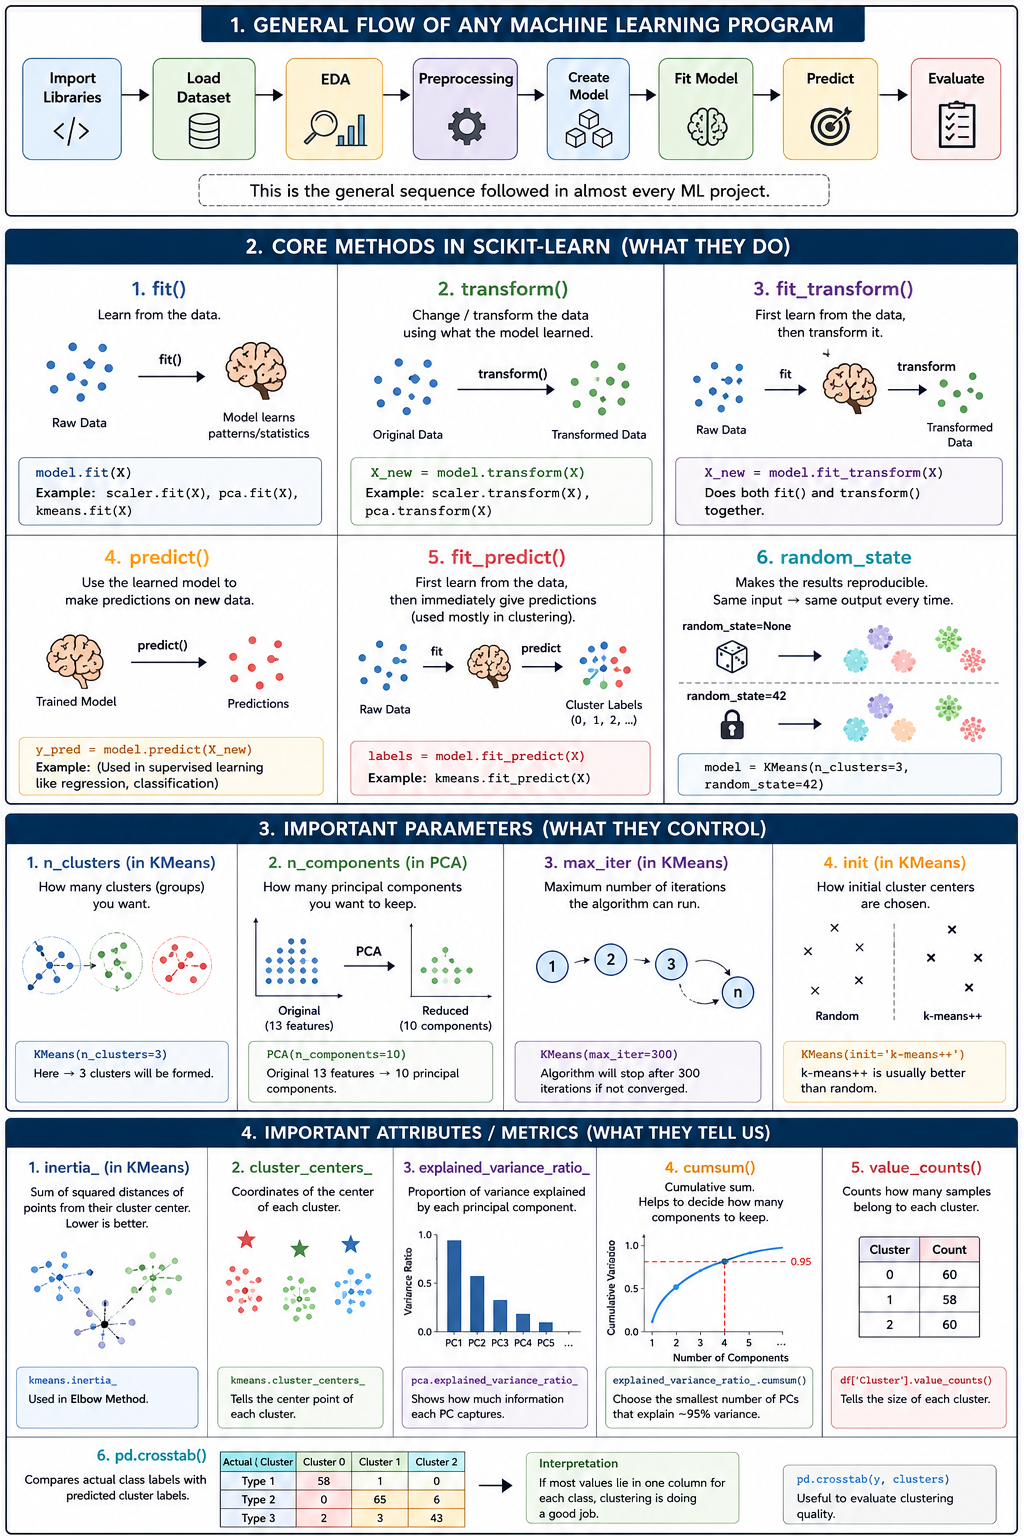

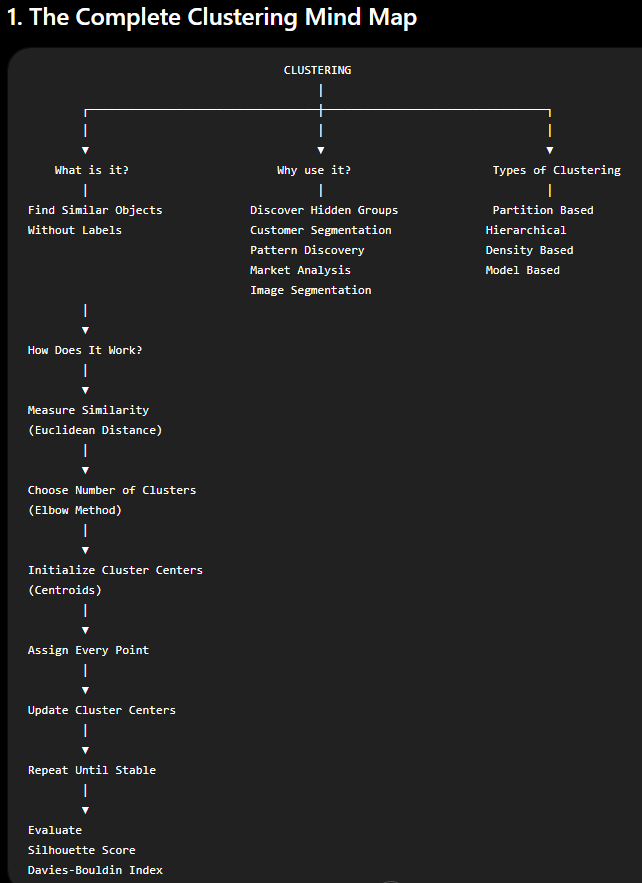

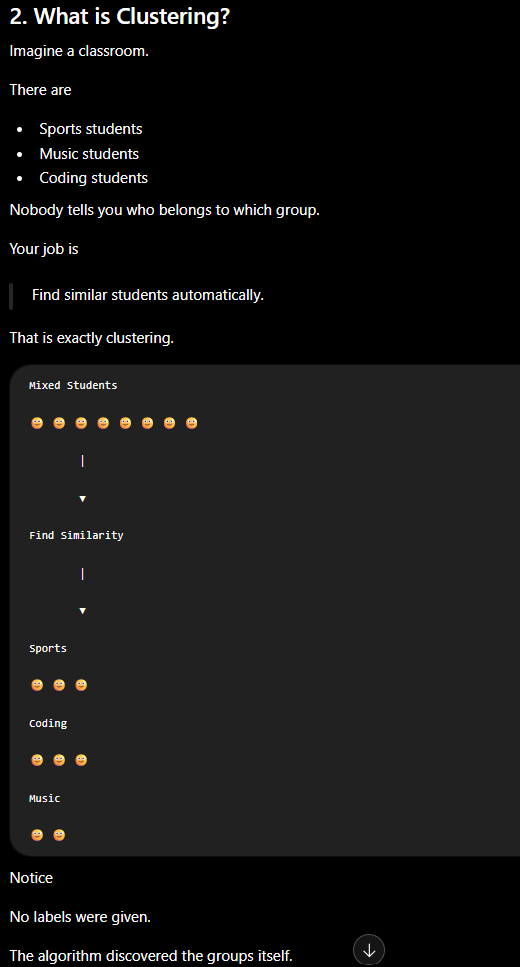

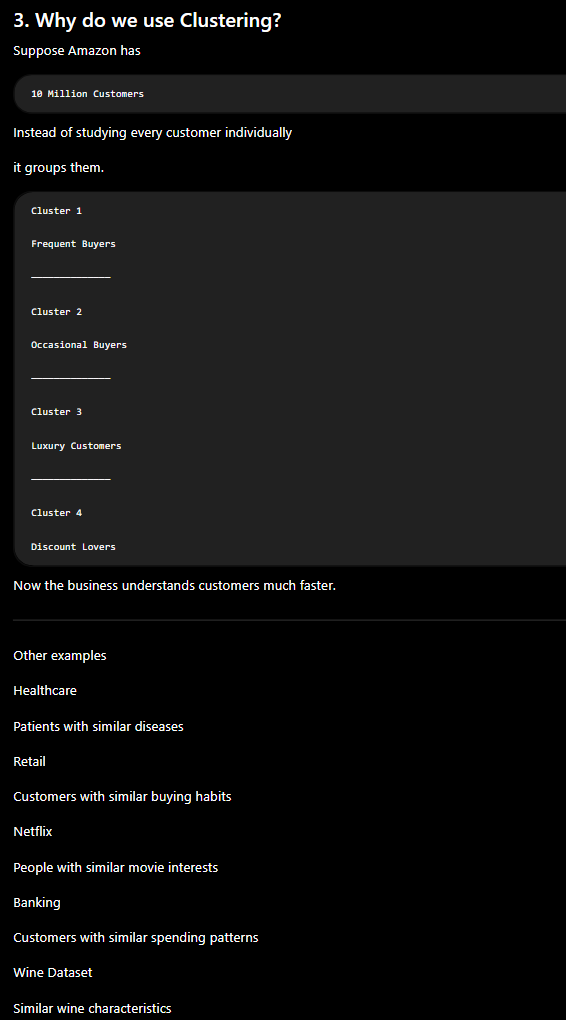

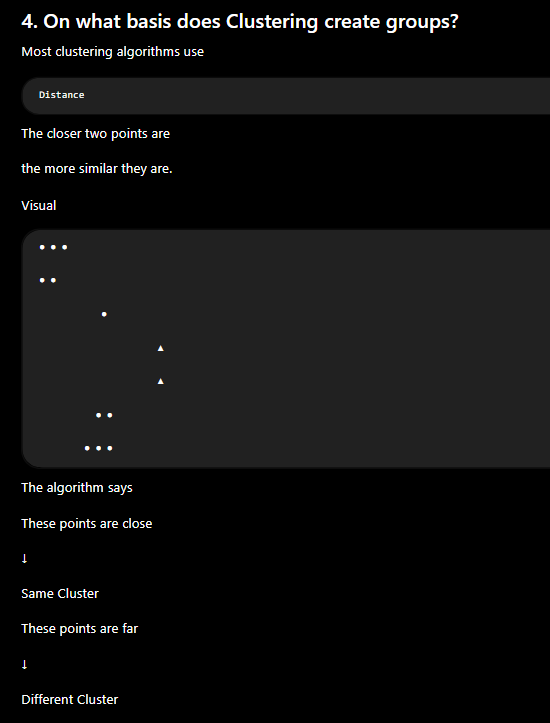

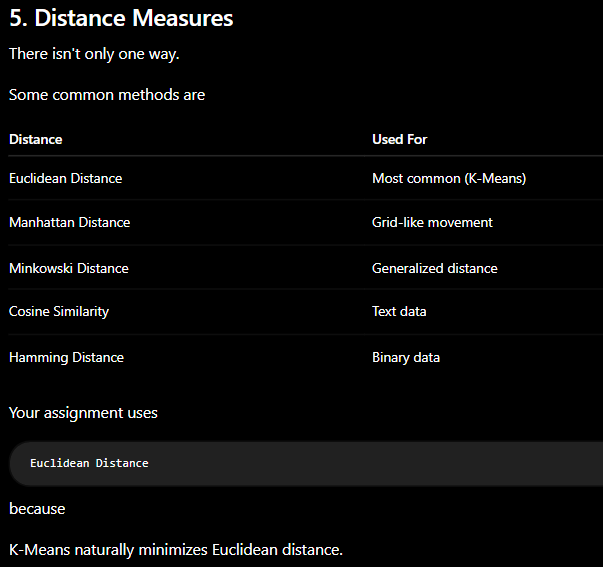

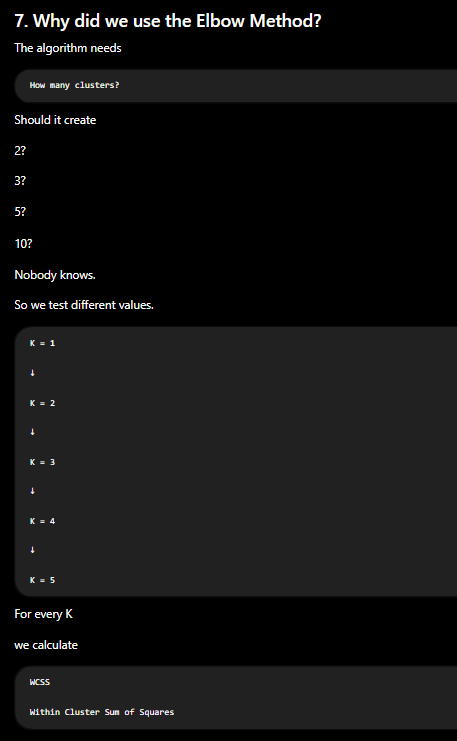

: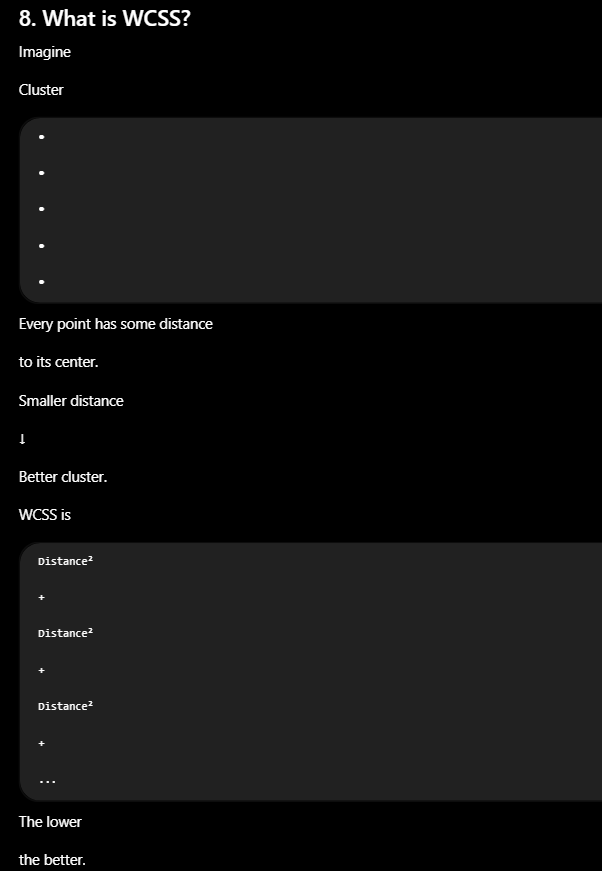

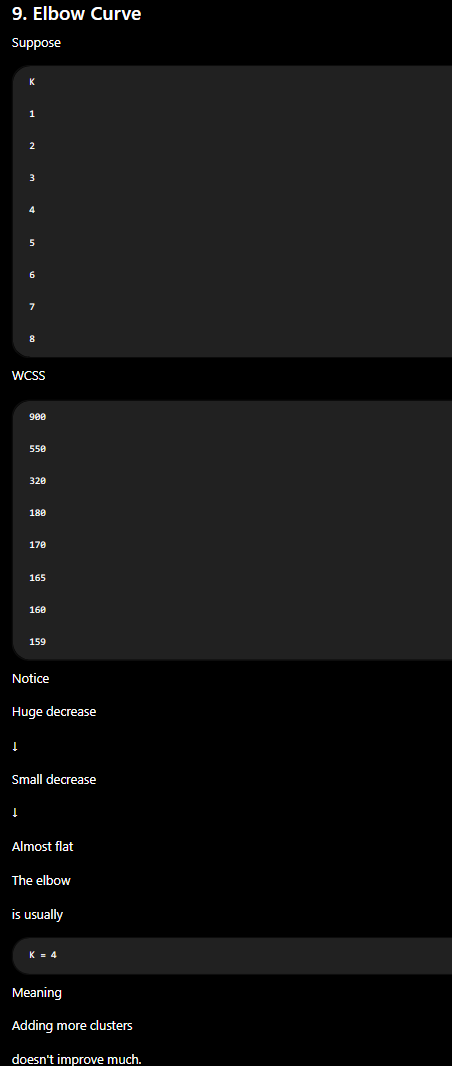

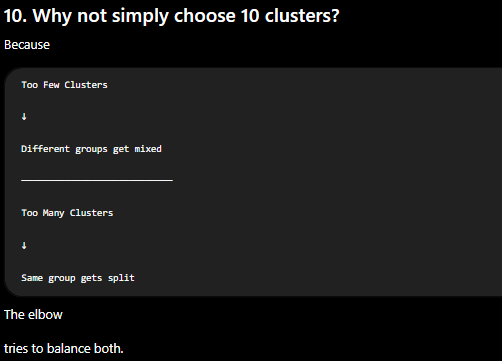

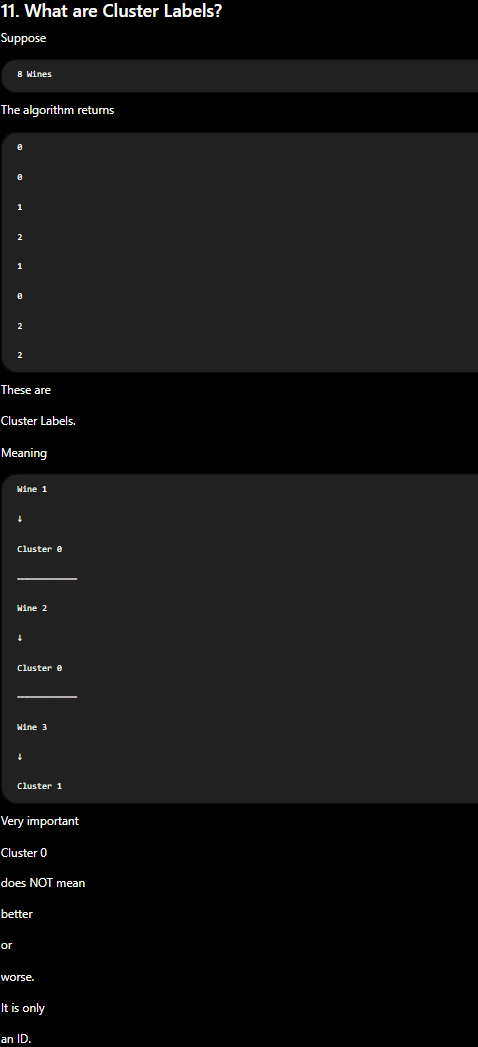

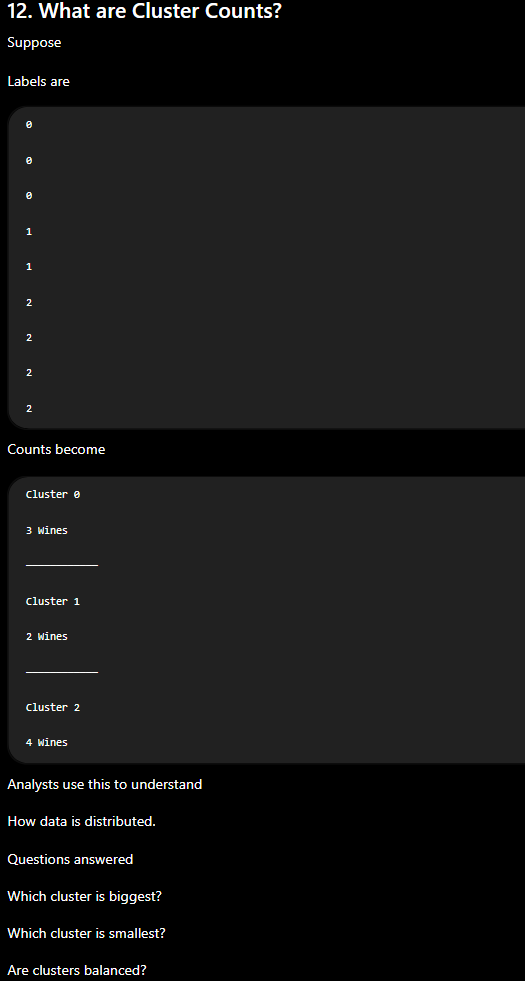

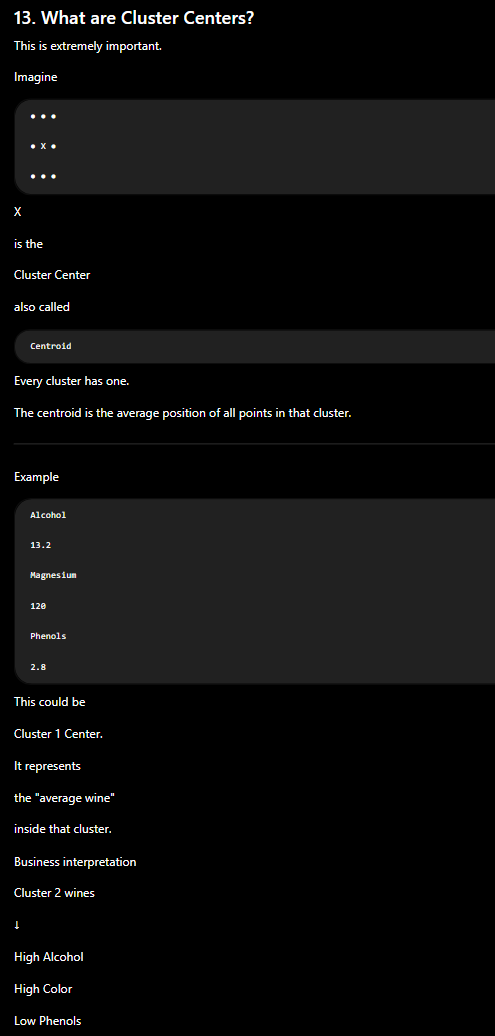

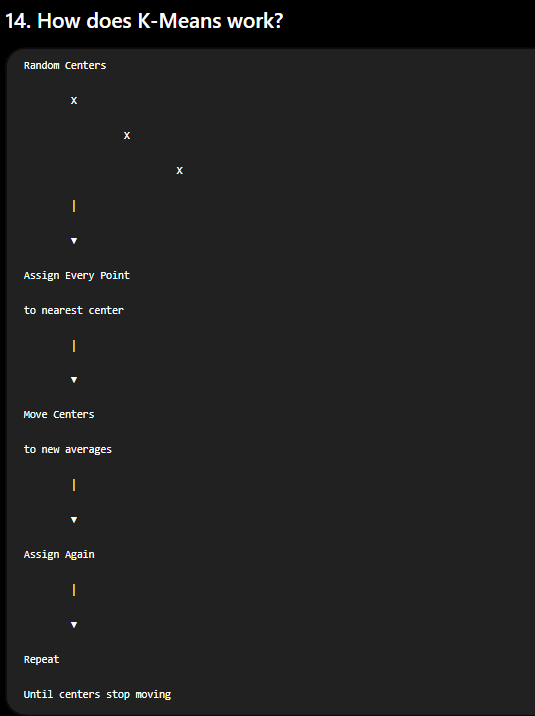

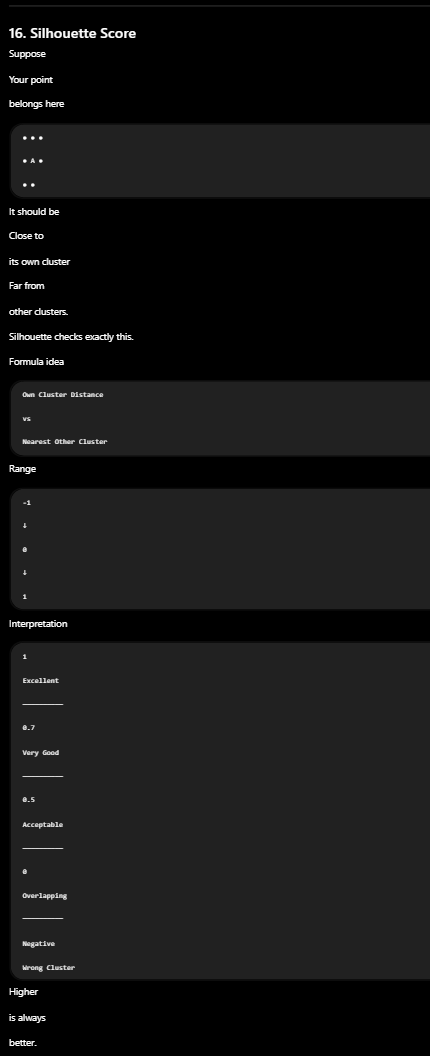

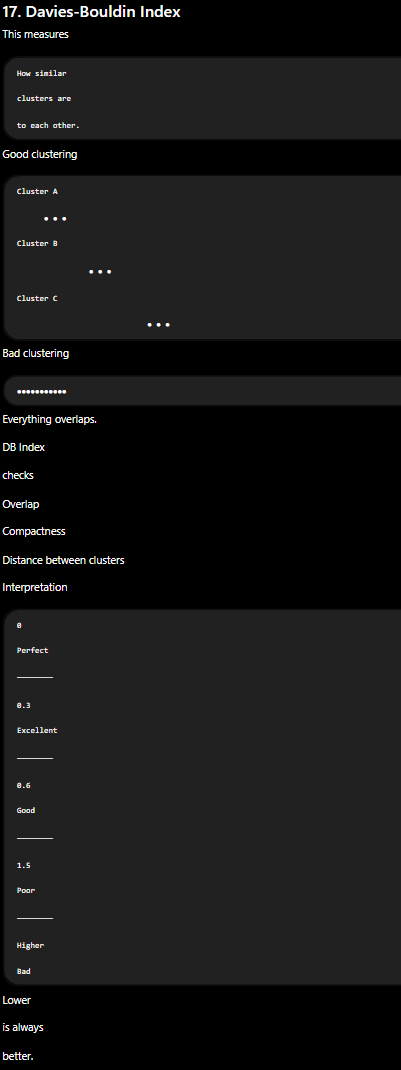

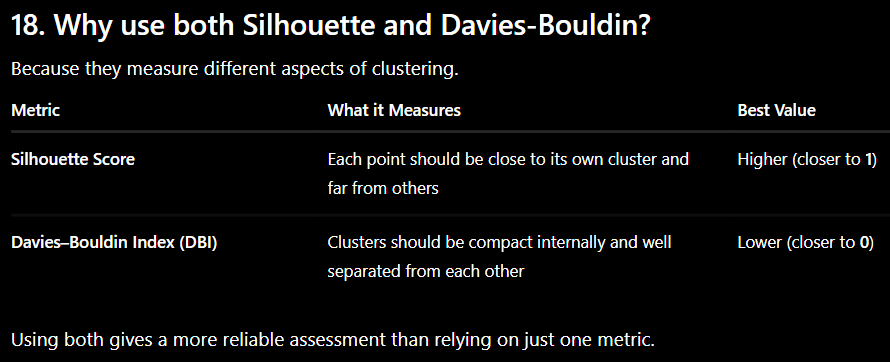

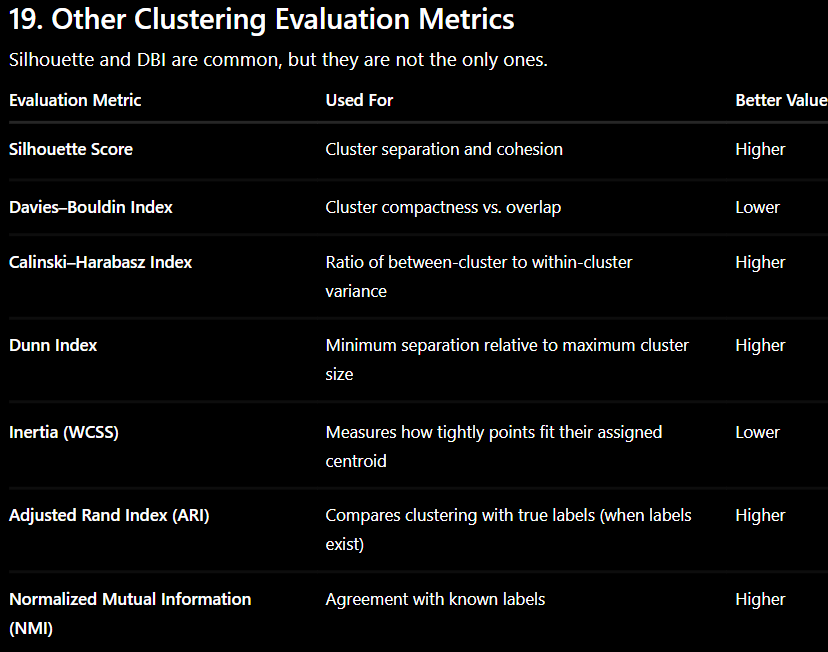

In [242]:
# Clustering
from sklearn.cluster import KMeans

# Evaluation Metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score

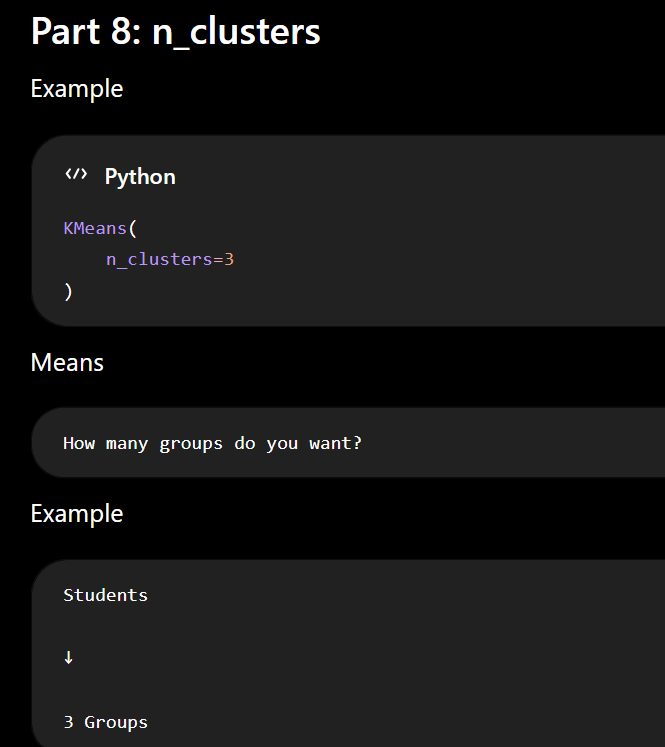

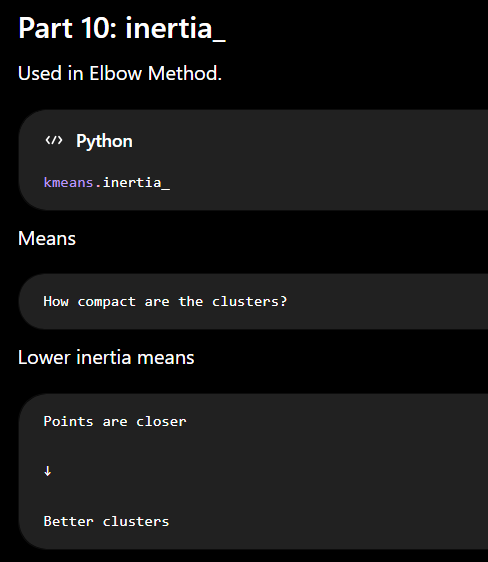

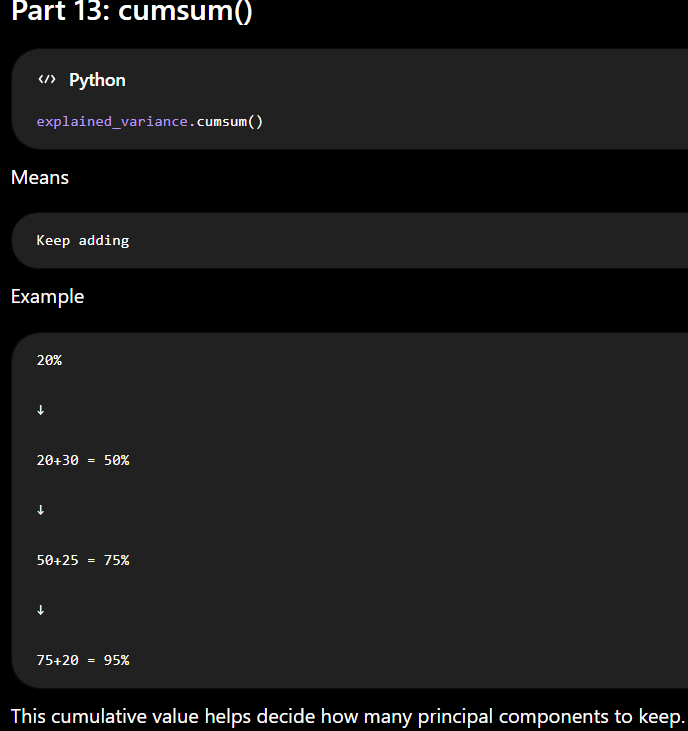

In [243]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

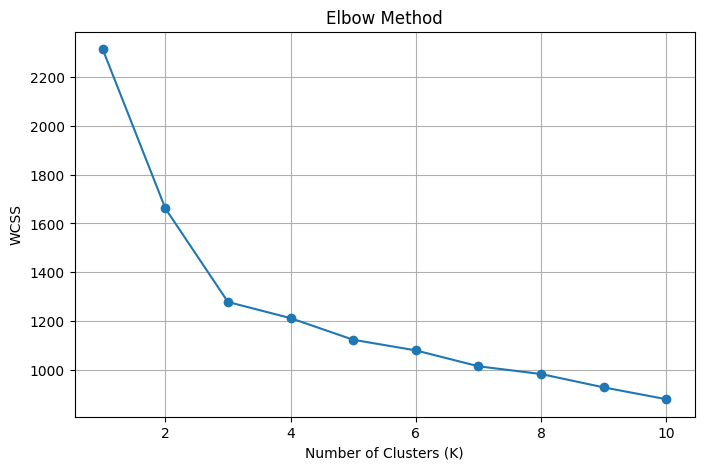

In [244]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.show()



The Elbow Method was used to determine the optimal number of clusters for the K-Means algorithm. The WCSS (Within Cluster Sum of Squares) decreases sharply from K=1 to K=3, indicating that adding clusters significantly improves cluster compactness during this range. After K=3, the decrease in WCSS becomes gradual, suggesting that adding more clusters provides only marginal improvement.

Therefore, K=3 is selected as the optimal number of clusters because it provides a good balance between clustering accuracy and model simplicity.

"From the Elbow Method graph, the WCSS decreases rapidly until K = 3 and then starts to flatten. This indicates that adding more than three clusters provides only a small improvement in cluster compactness. Therefore, K = 3 is selected as the optimal number of clusters."

K = 1

│

│ Dataset is treated as one large group.

│ High WCSS → Poor clustering.

│
\
▼

K = 2

│

│ Much better grouping.

│ Large reduction in WCSS.

│
\
▼

K = 3  ⭐

│

│ Biggest improvement achieved.

│ Natural groups are identified.

│ Best balance between simplicity and accuracy.

│
\
▼

K = 4,5,6...

│

│ WCSS still decreases,

│ but only by a small amount.

│ Additional clusters add complexity

│ without much benefit.

In [274]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled) # in the previous we have learnt how much clusters we needed by fitting the data so now we are using that data and fit_transform

the thing that we need to notice is we got the clusters but they are in array form so that is why in the following step we add them / assigned them in to the clusters

In [246]:
clusters

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [247]:
df["Cluster"] = clusters

df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Cluster
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


"clusters contains the cluster label predicted by the K-Means algorithm for every observation.

 The statement df['Cluster'] = clusters creates a new column named Cluster in the dataframe and stores the predicted cluster label for each row.

 This makes it easy to analyze, visualize, and compare the characteristics of each cluster using pandas operations such as groupby() and value_counts()."

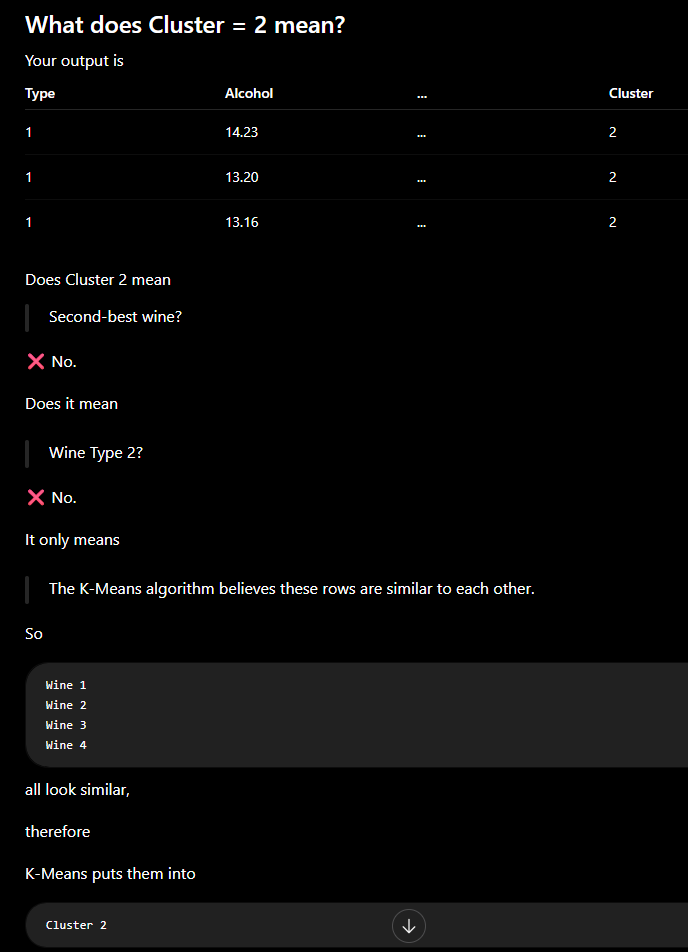

In [248]:
df["Cluster"].value_counts()

,count
Cluster,
0,65
2,62
1,51


In [249]:
silhouette = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score :", silhouette)

Silhouette Score : 0.2848589191898987


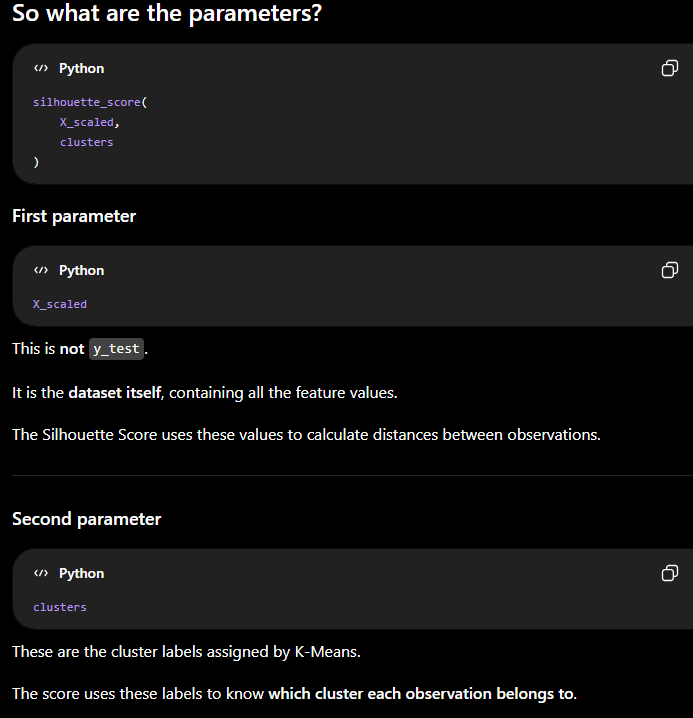

Why does silhouette_score() use X_scaled and clusters instead of y_test and y_pred?

"K-Means is an unsupervised learning algorithm, so there are no actual target labels like y_test. The Silhouette Score evaluates clustering quality by using the feature data (X_scaled) to compute distances between observations and the cluster labels (clusters) to determine each observation's assigned group. It measures how compact each cluster is and how well it is separated from other clusters without requiring any ground-truth labels."

In [250]:
db_index = davies_bouldin_score(
    X_scaled,
    clusters
)

print("Davies-Bouldin Index :", db_index)

Davies-Bouldin Index : 1.3891879777181648


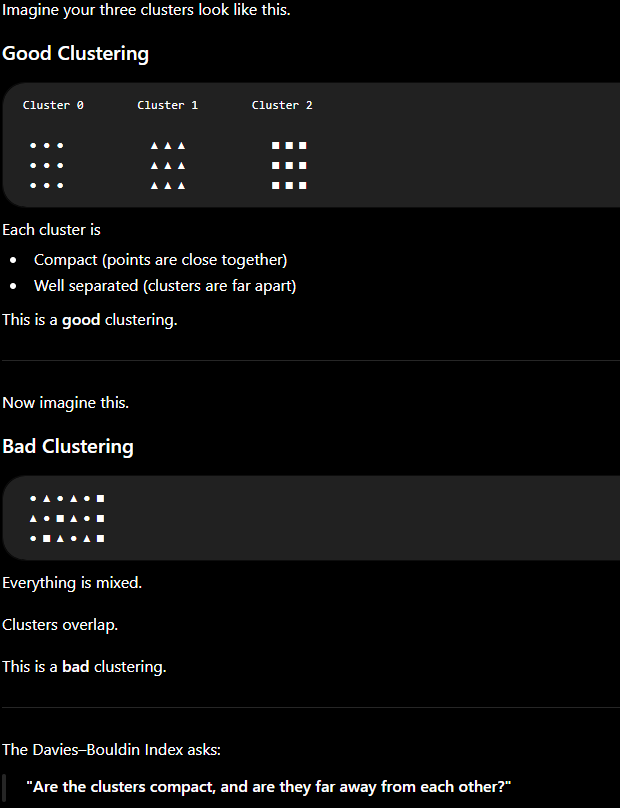

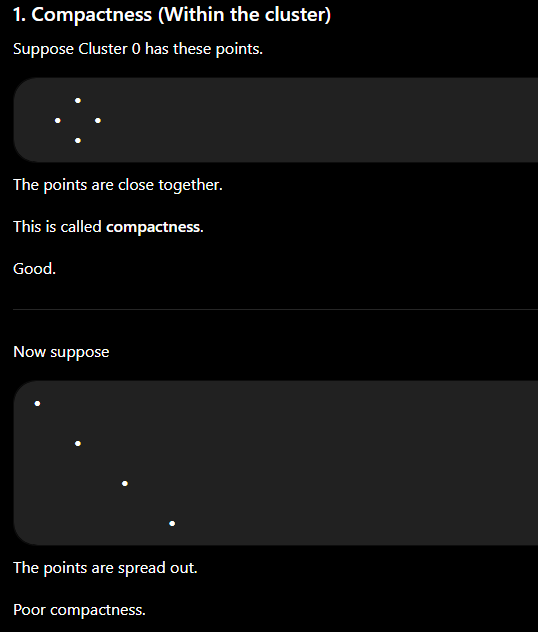

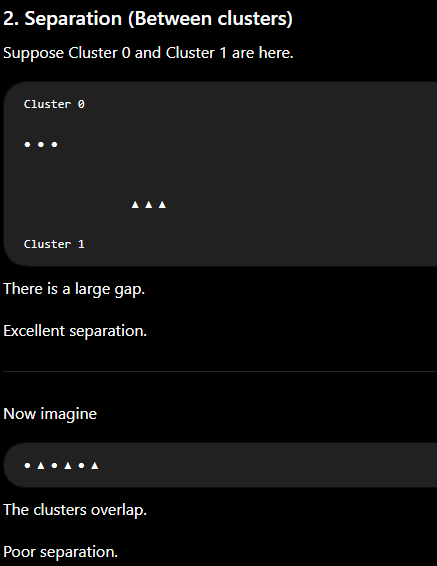

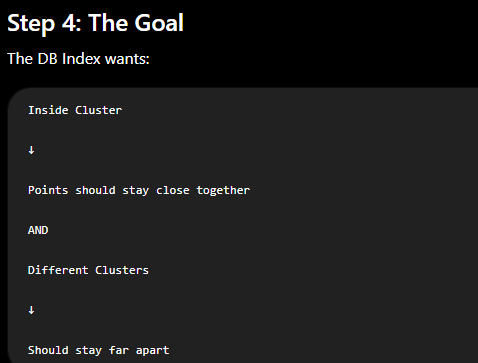

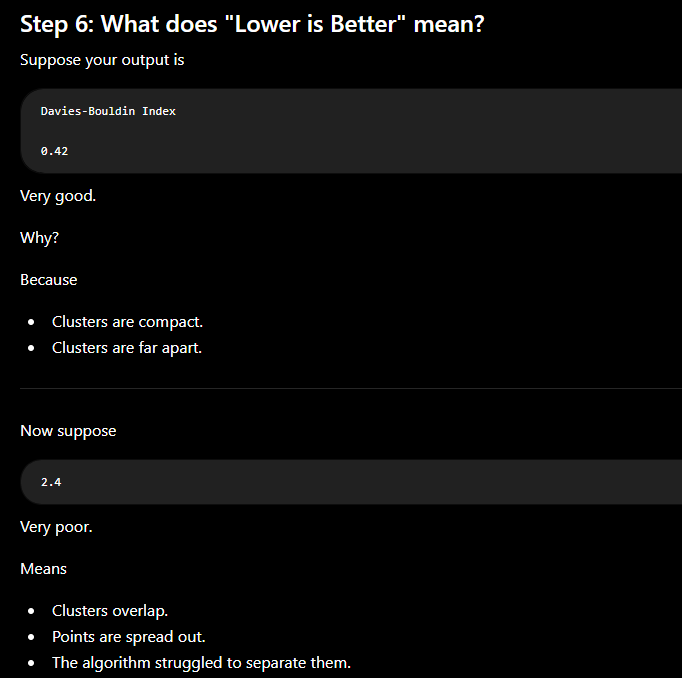

| Silhouette Score                                                            | Davies-Bouldin Index                                                       |
| --------------------------------------------------------------------------- | -------------------------------------------------------------------------- |
| Higher is better                                                            | Lower is better                                                            |
| Measures how close a point is to its own cluster compared to other clusters | Measures how compact clusters are and how far apart different clusters are |
| Range: -1 to 1                                                              | Range: 0 to ∞                                                              |
| Focuses on individual observations                                          | Focuses on overall cluster quality                                         |


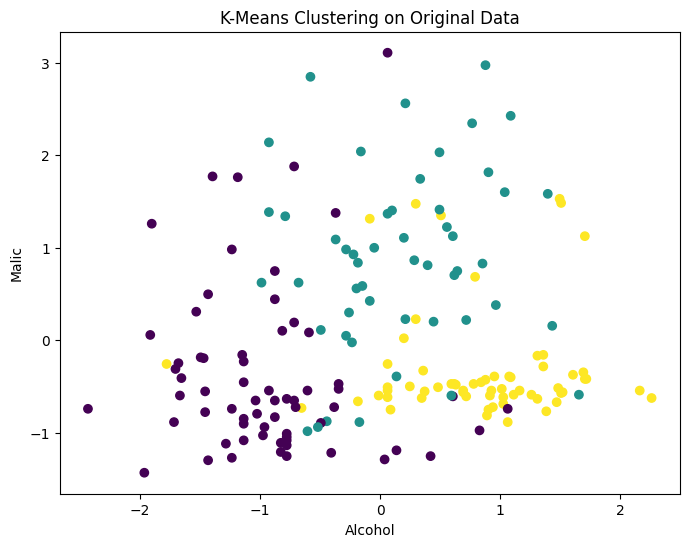

In [251]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled.iloc[:,0],
    X_scaled.iloc[:,1],
    c=clusters,
    cmap='viridis'
)

plt.xlabel(X_scaled.columns[0])
plt.ylabel(X_scaled.columns[1])
plt.title("K-Means Clustering on Original Data")

plt.show()

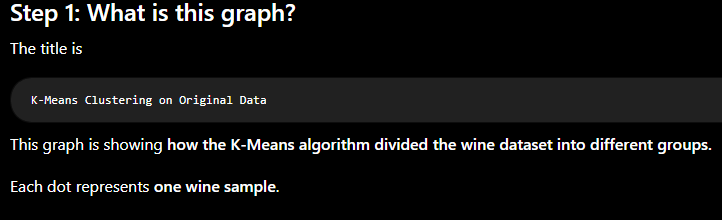

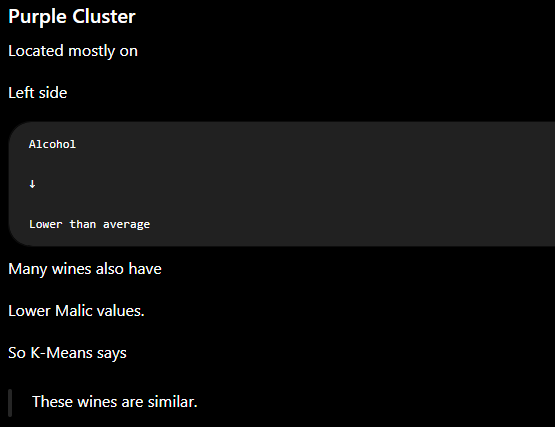

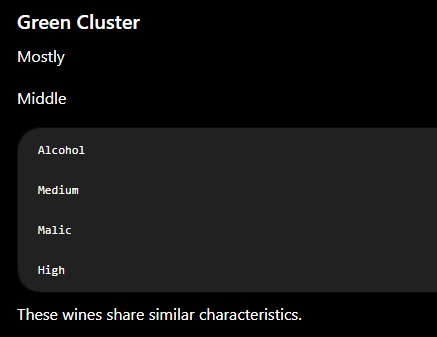

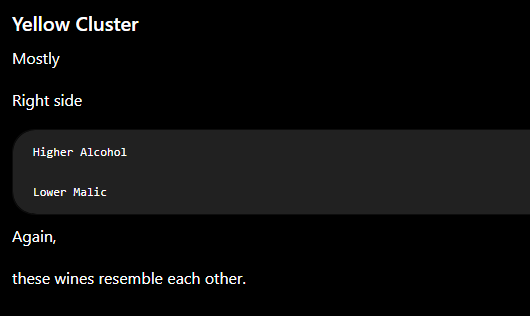

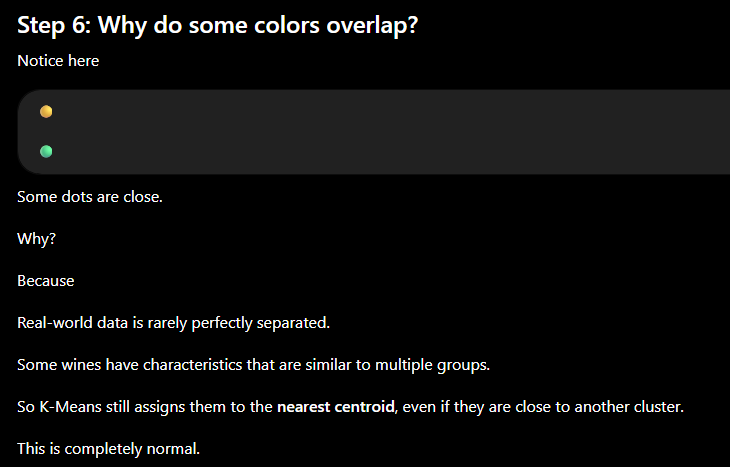

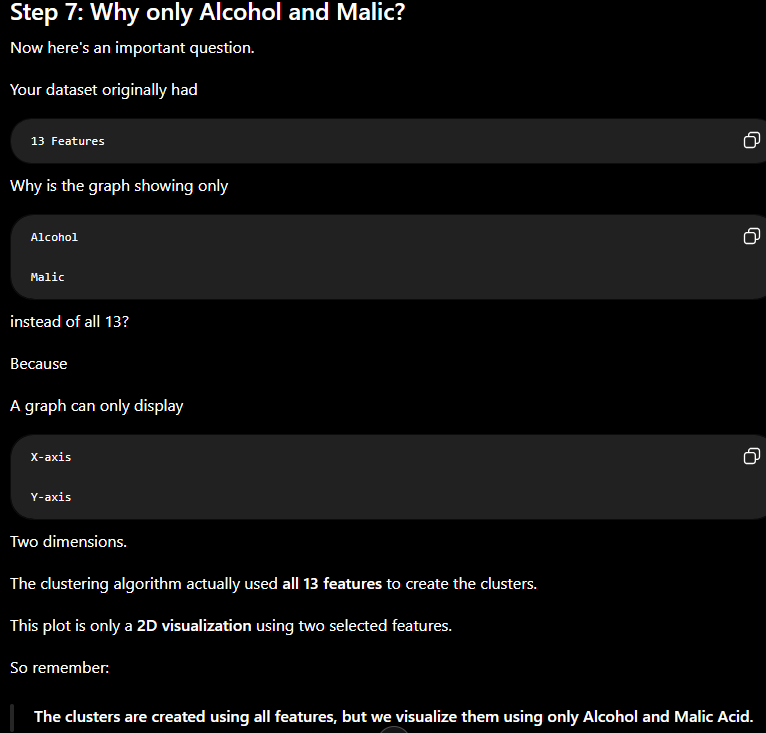


The scatter plot visualizes the clustering results obtained using the K-Means algorithm on the original dataset. Each point represents a wine sample, while different colors indicate different clusters assigned by the algorithm. The clusters are reasonably well separated, although a small overlap exists between some groups, which is expected in real-world datasets. This suggests that K-Means successfully identified three meaningful groups of wines based on their feature similarities.

In [252]:
pd.crosstab(
    df["Type"],
    df["Cluster"]
)

Cluster,0,1,2
Type,,,
1,0,0,59
2,65,3,3
3,0,48,0


####Clustering with PCA Data

PCA Dataset

      │
      ▼

Find Optimal K
 (Elbow Method)

      │
      ▼
Apply K-Means

      │
      ▼
Assign Cluster Labels

      │
      ▼
Visualize Clusters

      │
      ▼
Evaluate Clustering

      │
      ▼
Compare with Original Data

In [253]:
X_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139,-0.641443,1.020956
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416,0.308847,0.159701
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216,1.177834,0.113361
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593,-0.052544,0.239413
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700,-0.326819,-0.078366


The PCA transformation successfully reduced the dimensionality of the dataset while preserving most of its variability.

Business Insight:

A lower-dimensional dataset enables faster clustering, easier visualization, and reduced computational cost without significant information loss.

In [254]:
X_pca.shape

(178, 10)

In [255]:
wcss_pca = []

for i in range(1,11):

    kmeans_pca = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans_pca.fit(X_pca)

    wcss_pca.append(kmeans_pca.inertia_)

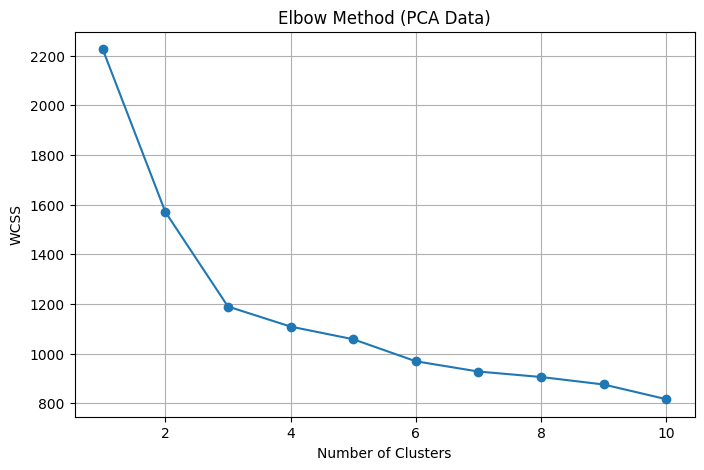

In [256]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss_pca,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method (PCA Data)")

plt.grid(True)

plt.show()

| Original Data             | PCA Data                  |
| ------------------------- | ------------------------- |
| 13 Features               | 10 Principal Components   |
| Elbow at K = 3            | Elbow at K = 3            |
| Higher-dimensional data   | Lower-dimensional data    |
| More computational effort | Less computational effort |
| Same natural grouping     | Same natural grouping     |


The Elbow Method produces the same optimal number of clusters (K = 3) before and after applying PCA. This indicates that PCA successfully reduced the dimensionality of the dataset while preserving its natural cluster structure. As a result, clustering can be performed more efficiently without a significant loss of information.

In [257]:
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42
)

pca_clusters = kmeans_pca.fit_predict(X_pca)

In [258]:
pca_clusters

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [259]:
X_pca["Cluster"] = pca_clusters

X_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Cluster
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139,-0.641443,1.020956,2
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416,0.308847,0.159701,2
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216,1.177834,0.113361,2
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593,-0.052544,0.239413,2
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700,-0.326819,-0.078366,2


In [260]:
X_pca["Cluster"].value_counts()

,count
Cluster,
0,65
2,62
1,51


In [261]:
kmeans_pca.cluster_centers_

array([[-3.69566084e-02, -1.77223945e+00,  1.86138728e-01,
         8.02397126e-02,  7.08780744e-02, -1.29805766e-01,
        -2.32728507e-03,  1.80153234e-02, -3.22512140e-02,
        -2.30035303e-02],
       [-2.72003575e+00,  1.12565126e+00, -2.39093241e-01,
         6.24569372e-02,  7.36759999e-02, -9.99252193e-02,
        -6.03831729e-02,  7.38798948e-03, -2.00269270e-02,
        -6.14683784e-02],
       [ 2.27619360e+00,  9.32054027e-01,  1.52803156e-03,
        -1.35498147e-01, -1.34912110e-01,  2.18283242e-01,
         5.21099249e-02, -2.49642497e-02,  5.02855192e-02,
         7.46793027e-02]])

In [262]:
silhouette_pca = silhouette_score(
    X_pca.drop("Cluster", axis=1),
    pca_clusters
)

print("Silhouette Score :", silhouette_pca)

Silhouette Score : 0.29867482943692886


In [263]:
db_pca = davies_bouldin_score(
    X_pca.drop("Cluster", axis=1),
    pca_clusters
)

print("Davies-Bouldin Index :", db_pca)

Davies-Bouldin Index : 1.3363263335155773


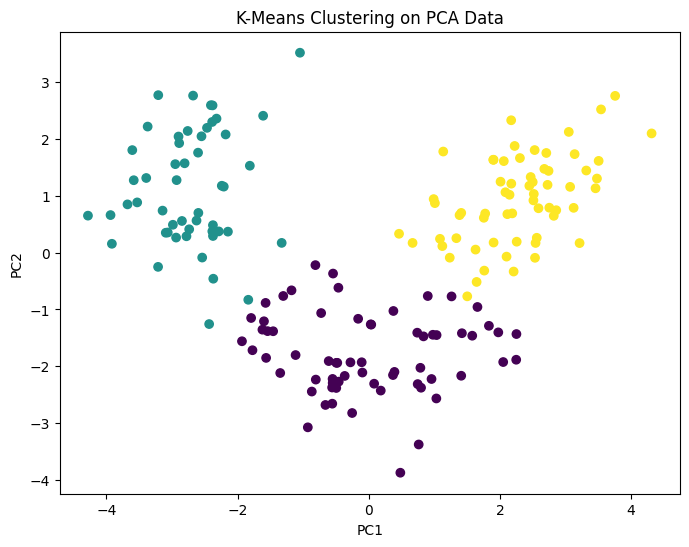

In [264]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    c=pca_clusters,
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering on PCA Data")

plt.show()

In [265]:
pd.crosstab(
    y,
    pca_clusters
)

col_0,0,1,2
Type,,,
1,0,0,59
2,65,3,3
3,0,48,0


####Comparison and Analysis

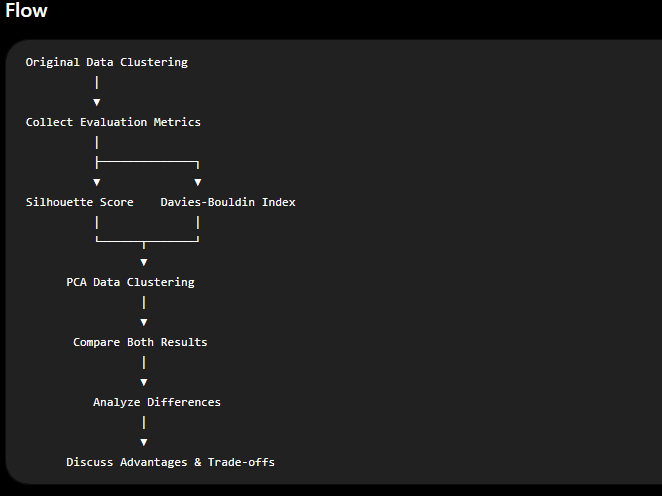

In [266]:
comparison = pd.DataFrame({
    "Metric": ["Silhouette Score", "Davies-Bouldin Index"],
    "Original Data": [silhouette, db_index],
    "PCA Data": [silhouette_pca, db_pca]
})

comparison

,Metric,Original Data,PCA Data
0,Silhouette Score,0.284859,0.298675
1,Davies-Bouldin Index,1.389188,1.336326


PCA successfully reduced the dimensionality of the dataset.

Most of the important information was preserved.

Removing redundant information helped K-Means form slightly better clusters.

The improvement is modest rather than dramatic, indicating that the original dataset was already reasonably structured.

"The PCA-transformed dataset performed slightly better. The Silhouette Score increased from 0.2849 to 0.2987, indicating improved cluster separation, while the Davies–Bouldin Index decreased from 1.3892 to 1.3363, indicating more compact and better-separated clusters. This suggests that PCA reduced redundancy and preserved the important structure of the data, allowing K-Means to form slightly higher-quality clusters."

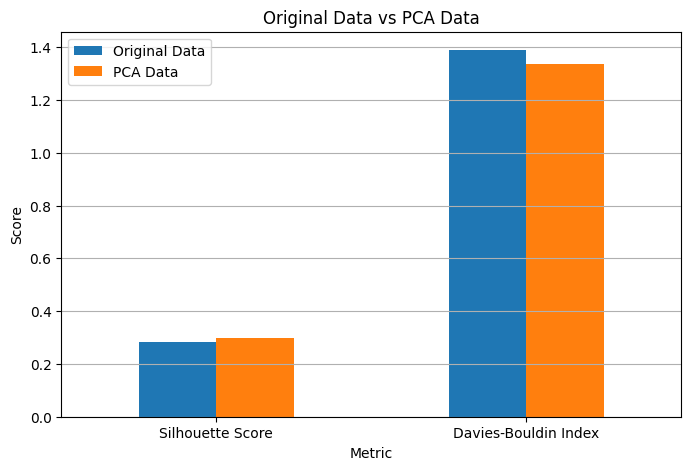

In [267]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Original Data vs PCA Data")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(axis='y')

plt.show()

The PCA-transformed dataset achieved slightly better clustering performance than the original dataset.

The increase in the Silhouette Score indicates improved separation between clusters.

The decrease in the Davies–Bouldin Index indicates that the clusters became more compact and distinct.

The improvement is incremental rather than dramatic, showing that the original dataset already had a reasonably good cluster structure and PCA refined it further.



The comparison between clustering on the original dataset and the PCA-transformed dataset shows that PCA successfully reduced the dimensionality of the data while preserving its essential structure.

 The PCA-based model achieved a slightly higher Silhouette Score and a lower Davies–Bouldin Index, indicating improved cluster separation and compactness.

  These findings demonstrate that PCA is an effective preprocessing technique that simplifies the dataset, reduces computational complexity, and slightly enhances clustering performance without significant information loss.

In [268]:
df["Cluster"].value_counts()

,count
Cluster,
0,65
2,62
1,51


In [269]:
X_pca["Cluster"].value_counts()

,count
Cluster,
0,65
2,62
1,51


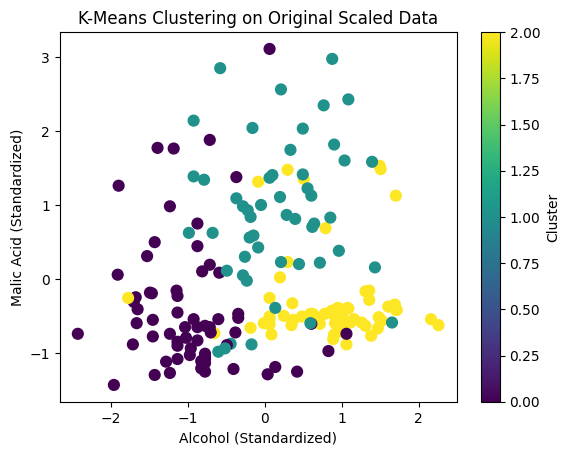

In [279]:
plt.scatter(
    X_scaled.iloc[:,0],
    X_scaled.iloc[:,1],
    c=clusters,
    cmap="viridis",
    s = 60
    )

plt.title("K-Means Clustering on Original Scaled Data")
plt.xlabel("Alcohol (Standardized)")
plt.ylabel("Malic Acid (Standardized)")
plt.colorbar(label="Cluster")
plt.show()


The scatter plot visualizes the clustering results obtained using the K-Means algorithm on the standardized original dataset.

Each point represents a wine sample, while the colors indicate the cluster assigned by the algorithm.

Three distinct clusters can be observed, suggesting that wines with similar chemical characteristics have been grouped together.

Although a small amount of overlap exists between some clusters, the overall separation indicates that K-Means successfully identified meaningful patterns in the dataset.

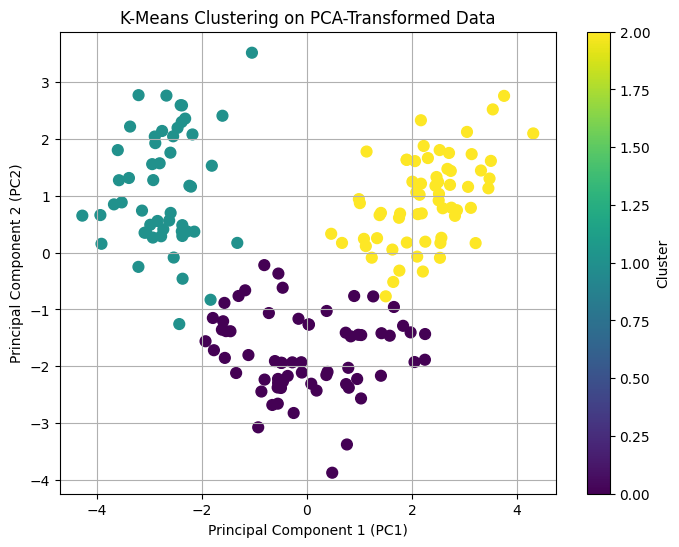

In [278]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    c=pca_clusters,
    cmap="viridis",
    s=60
)

plt.title("K-Means Clustering on PCA-Transformed Data")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

### Observation

The scatter plot shows the K-Means clustering results on the PCA-transformed dataset using the first two principal components.

 Three well-defined clusters can be observed with minimal overlap between them. Compared to the original dataset, the clusters appear more compact and better separated, indicating that PCA successfully reduced redundancy and preserved the underlying structure of the data.

 This improved visualization supports the clustering evaluation metrics obtained after PCA.

| Original Dataset Plot                                 | PCA Dataset Plot                                      |
| ----------------------------------------------------- | ----------------------------------------------------- |
| **Title:** K-Means Clustering on Original Scaled Data | **Title:** K-Means Clustering on PCA-Transformed Data |
| **X-axis:** Alcohol (Standardized)                    | **X-axis:** Principal Component 1 (PC1)               |
| **Y-axis:** Malic Acid (Standardized)                 | **Y-axis:** Principal Component 2 (PC2)               |
| **Colorbar:** Cluster                                 | **Colorbar:** Cluster                                 |


| Original Data                 | PCA Data                        |
| ----------------------------- | ------------------------------- |
| Uses Alcohol and Malic Acid   | Uses PC1 and PC2                |
| Some cluster overlap          | Much less overlap               |
| Clusters moderately separated | Clusters more clearly separated |
| Original feature space        | Reduced feature space           |
| Harder to visualize           | Easier to visualize             |


In [272]:
pd.crosstab(
    y,
    clusters
)

col_0,0,1,2
Type,,,
1,0,0,59
2,65,3,3
3,0,48,0


In [273]:
pd.crosstab(
    y,
    pca_clusters
)

col_0,0,1,2
Type,,,
1,0,0,59
2,65,3,3
3,0,48,0


# Conclusion

The Wine dataset was successfully analyzed using Exploratory Data Analysis, Principal Component Analysis (PCA), and K-Means clustering. PCA reduced the dimensionality of the dataset from 13 original features to 10 principal components while preserving approximately 96% of the total variance.

K-Means clustering was applied to both the original dataset and the PCA-transformed dataset. The PCA-based clustering achieved a slightly higher Silhouette Score and a lower Davies–Bouldin Index, indicating improved cluster separation and compactness.

Overall, PCA simplified the dataset while maintaining its essential information, allowing K-Means to produce slightly better clustering results.

### Trade-offs Between Original Data and PCA

Original Data:
- Retains all original feature information.
- Easier to interpret because each feature has a direct physical meaning.
- Higher computational cost.
- May contain redundant and correlated features.

PCA Data:
- Reduces dimensionality and removes redundancy.
- Faster for clustering and visualization.
- Principal Components are harder to interpret because they are combinations of original features.
- May lose a small amount of information during dimensionality reduction.

# Recommendation

Use PCA before clustering when:

• The dataset contains many correlated variables.

• Faster computation is required.

• Data visualization is important.

Use the original dataset when:

• Interpretability of the original features is essential.

• The number of features is already small.

• Preserving every original variable is more important than reducing dimensionality.